In [2946]:
import pandas
import copy
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import seaborn as sbn
import sys
import matplotlib.pyplot as plt


# show all elements of a dataframe
# pandas.set_option("display.max_rows", None)
pandas.set_option("display.max_columns", None)


sys.path.append("../../src/")

In [2947]:
races = pd.read_csv('../dataset/preprocessedRaces.csv', sep=",")
races.head()

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,date,climb/length,median_delta,std_delta
0,tour-de-france/1978/stage-6,Tour de France,100,NaN,162000,1101,1.0,1241,NaN,1,0,0,1978-07-05,0.006796,27.0,6.847590
1,vuelta-a-espana/2016/stage-14,Vuelta a España,80,100.0,196000,5575,5.0,821,NaN,1,0,0,2016-09-03,0.028444,1957.0,873.835670
2,tour-de-france/2019/stage-21,Tour de France,100,120.0,128000,781,1.0,1699,NaN,1,0,0,2019-07-28,0.006102,29.0,44.079531
3,volta-a-catalunya/1999/prologue,Volta Ciclista a Catalunya,50,NaN,8100,68,NaN,804,NaN,1,0,0,1999-06-17,0.008395,53.0,27.154498
4,tour-de-france/2022/stage-9,Tour de France,100,120.0,192900,3743,3.0,1551,24.0,1,0,0,2022-07-10,0.019404,1376.0,675.354230


In [2948]:
races.isna().sum()

_url                      0
name                      0
points                    0
uci_points             3682
length                    0
climb_total               0
profile                2408
startlist_quality         0
average_temperature    5076
is_tarmac                 0
is_cobbled                0
is_gravel                 0
date                      0
climb/length              0
median_delta              0
std_delta                 0
dtype: int64

In [2949]:
races.dtypes

_url                    object
name                    object
points                   int64
uci_points             float64
length                   int64
climb_total              int64
profile                float64
startlist_quality        int64
average_temperature    float64
is_tarmac                int64
is_cobbled               int64
is_gravel                int64
date                    object
climb/length           float64
median_delta           float64
std_delta              float64
dtype: object

In [2950]:
cyclists = pd.read_csv('../dataset/preprocessedCyclists.csv', sep=",")
cyclists.head()

,name,BMI,median position,AVG position,# cyclist races,nationality,continent,geo area,birth_year,AVG weighted position,AVG position Autumn,AVG position Spring,AVG position Summer,AVG position Winter,AVG position Q1,AVG position Q2,AVG position Q3,AVG position Q4,std_dev position
0,sean-kelly,23.770000,6,16,629,Ireland,Europe,Northern Europe,1956.0,22,11.0,7.0,22.0,20.0,8.0,10.0,23.0,18.0,24.497844
1,gerrie-knetemann,19.959003,38,48,271,Netherlands,Europe,Western Europe,1951.0,66,56.0,15.0,58.0,NaN,15.0,18.0,66.0,NaN,46.993017
2,rene-bittinger,22.790000,42,47,146,France,Europe,Western Europe,1954.0,54,15.0,31.0,55.0,NaN,17.0,37.0,56.0,18.0,32.648452
3,joseph-bruyere,23.086015,8,16,48,Belgium,Europe,Western Europe,1948.0,21,29.0,11.0,19.0,NaN,5.0,14.0,23.0,NaN,19.723611
4,sven-ake-nilsson,21.300000,25,33,145,Sweden,Europe,Northern Europe,1951.0,38,17.0,12.0,38.0,NaN,14.0,27.0,37.0,16.0,26.276978


In [2951]:
cyclists.isna().sum()

name                        0
BMI                         0
median position             0
AVG position                0
# cyclist races             0
nationality                 0
continent                   0
geo area                    0
birth_year                  0
AVG weighted position       0
AVG position Autumn      2879
AVG position Spring       737
AVG position Summer      1945
AVG position Winter      4523
AVG position Q1          1694
AVG position Q2          1023
AVG position Q3          2280
AVG position Q4          4270
std_dev position            0
dtype: int64

In [2952]:
cyclists.dtypes

name                      object
BMI                      float64
median position            int64
AVG position               int64
# cyclist races            int64
nationality               object
continent                 object
geo area                  object
birth_year               float64
AVG weighted position      int64
AVG position Autumn      float64
AVG position Spring      float64
AVG position Summer      float64
AVG position Winter      float64
AVG position Q1          float64
AVG position Q2          float64
AVG position Q3          float64
AVG position Q4          float64
std_dev position         float64
dtype: object

In [2953]:
placements = pd.read_csv('../dataset/preprocessedPlacements.csv', sep=",")
placements.head()

,position,cyclist,cyclist_age,cyclist_team,delta,date,_url,year
0,0,georges-pintens,24,norway-1987,0,1970-04-25,amstel-gold-race/1970/result,1970
1,1,willy-van-neste,26,norway-1987,0,1970-04-25,amstel-gold-race/1970/result,1970
2,2,andre-dierickx,23,spain-1991,22,1970-04-25,amstel-gold-race/1970/result,1970
3,3,eric-leman,24,spain-1991,33,1970-04-25,amstel-gold-race/1970/result,1970
4,4,joseph-schoeters,23,NaN,33,1970-04-25,amstel-gold-race/1970/result,1970


In [2954]:
placements.isna().sum()

position             0
cyclist              0
cyclist_age          0
cyclist_team    159161
delta                0
date                 0
_url                 0
year                 0
dtype: int64

In [2955]:
placements.dtypes

position         int64
cyclist         object
cyclist_age      int64
cyclist_team    object
delta            int64
date            object
_url            object
year             int64
dtype: object

# Clustering for cyclists

## Outliers Detection

In [2956]:
def show_hist_and_box_plot(dataframe, column_name):
    column = dataframe[column_name]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Histogram 
    sbn.histplot(column, bins='sturges', ax=axes[0])
    axes[0].set_title(f'Histogram of {column.name}', fontweight='bold')
    axes[0].set_xlabel(column.name) 
    axes[0].set_ylabel('Frequency')
    
    # Boxplot
    boxplot_dict = axes[1].boxplot(column[~np.isnan(column)])  # Removes the NaNs to avoid problems
    axes[1].set_title(f'Boxplot of {column.name}', fontweight='bold')
    axes[1].set_xlabel(column.name)
    
    # Extraction of the outliers from the boxplot and printing of them
    outliers = [flier.get_ydata() for flier in boxplot_dict['fliers']]
    outliers_values = list({value for sublist in outliers for value in sublist})

    plt.tight_layout()  # Avoid overlapping
    plt.show()

    print(f"Outliers in {column.name}: {outliers_values}")

In [2957]:
def calculate_outlier_bounds(dataframe, column_name):
    Q1 = dataframe[column_name].quantile(0.25)
    Q3 = dataframe[column_name].quantile(0.75)
    IQR = Q3 - Q1
    min_ = dataframe[column_name].min()
    max_ = dataframe[column_name].max()
    lower_bound = max(min_, Q1 - 1.5 * IQR)
    upper_bound = min(max_, Q3 + 1.5 * IQR)
    return {"lower": lower_bound, "upper": upper_bound}

Feature selection based on NAN values and high correlation

In [2958]:
numeric_columns = ['BMI', 'median position', 'std_dev position', '# cyclist races', 'birth_year']
numeric_cyclists_df = cyclists[numeric_columns]
numeric_cyclists_df

,BMI,median position,std_dev position,# cyclist races,birth_year
0,23.770000,6,24.497844,629,1956.0
1,19.959003,38,46.993017,271,1951.0
2,22.790000,42,32.648452,146,1954.0
3,23.086015,8,19.723611,48,1948.0
4,21.300000,25,26.276978,145,1951.0
...,...,...,...,...,...
6090,19.696783,173,0.000000,1,1969.0
6091,20.031931,17,0.000000,1,1965.0
6092,25.450000,54,0.000000,1,1992.0
6093,20.011635,38,0.000000,1,1948.0


,BMI,median position,std_dev position,# cyclist races,birth_year
BMI,1.000000,0.007206,0.048828,-0.022857,-0.134499
median position,0.007206,1.000000,0.258890,-0.080105,0.486306
std_dev position,0.048828,0.258890,1.000000,0.356324,0.248989
# cyclist races,-0.022857,-0.080105,0.356324,1.000000,0.161916
birth_year,-0.134499,0.486306,0.248989,0.161916,1.000000


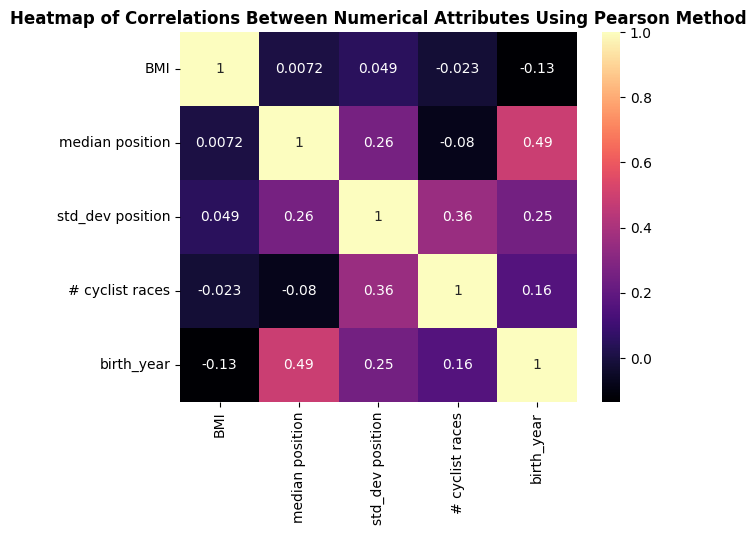

In [2959]:
pearson_matrix = numeric_cyclists_df.corr(method='pearson')
display(pearson_matrix)
sbn.heatmap(pearson_matrix, annot=True, cmap="magma")
plt.title("Heatmap of Correlations Between Numerical Attributes Using Pearson Method", fontweight='bold')
plt.show()
plt.close()

We will now display the distributions of the selected columns and address the most extreme outliers based on these initial distributions, essentially taking a snapshot of the initial state of the dataframe _cyclists_. We will not adopt a cumulative approach, where the removal of outliers from one column would affect the subsequent distributions of the other columns

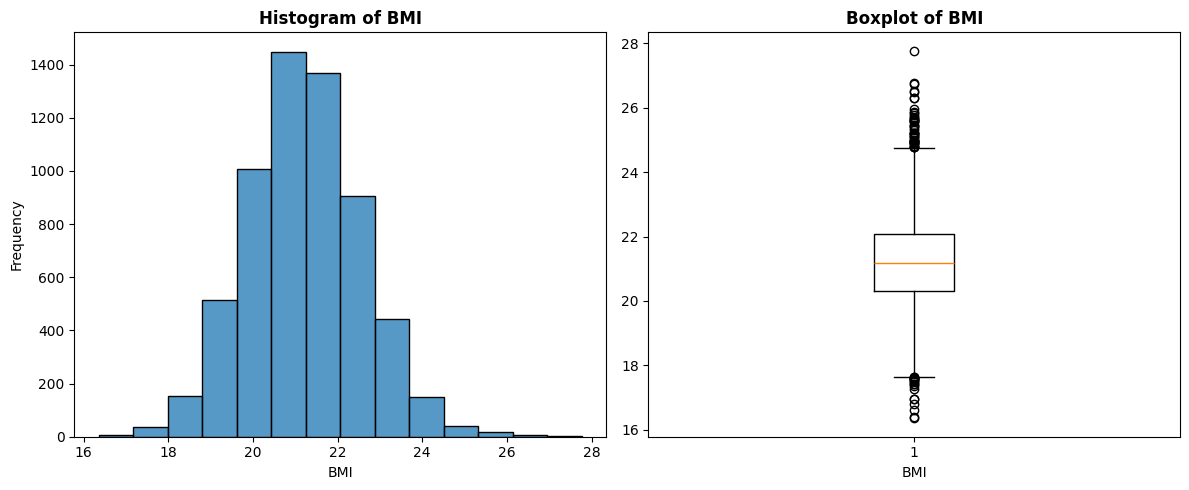

Outliers in BMI: [np.float64(25.20022254995826), np.float64(26.49), np.float64(26.78), np.float64(26.3), np.float64(24.807923763767764), np.float64(25.36941027818859), np.float64(27.77), np.float64(26.29494847074345), np.float64(25.607467548760734), np.float64(24.96), np.float64(25.95), np.float64(16.41), np.float64(17.364928022068078), np.float64(16.6), np.float64(16.96844793244452), np.float64(17.565204979689348), np.float64(17.412665529606812), np.float64(17.612939045572052), np.float64(17.62), np.float64(17.51), np.float64(17.263427240941304), np.float64(17.43167412484733), np.float64(26.53), np.float64(25.66), np.float64(25.14), np.float64(25.43), np.float64(25.31), np.float64(26.75), np.float64(25.22), np.float64(25.76), np.float64(24.78), np.float64(24.911001262515327), np.float64(24.97), np.float64(24.91), np.float64(25.59), np.float64(25.88), np.float64(25.83), np.float64(25.01), np.float64(24.786893547252976), np.float64(25.1), np.float64(24.954337414105275), np.float64(25.12

,Name,Column,Lower Bound,Upper Bound,Outlier Value
14,javier-francisco-elorriaga,BMI,17.64,24.76,26.53
27,marc-demeyer,BMI,17.64,24.76,25.66
241,svein-tuft,BMI,17.64,24.76,25.14
466,massimiliano-mori,BMI,17.64,24.76,25.43
565,john-degenkolb,BMI,17.64,24.76,25.31
...,...,...,...,...,...
5800,paul-willerton,BMI,17.64,24.76,16.35
5889,brian-petersen,BMI,17.64,24.76,25.20
6001,marc-de-block,BMI,17.64,24.76,24.87
6085,bjorn-backmann,BMI,17.64,24.76,25.61


Number of outliers in BMI: 66


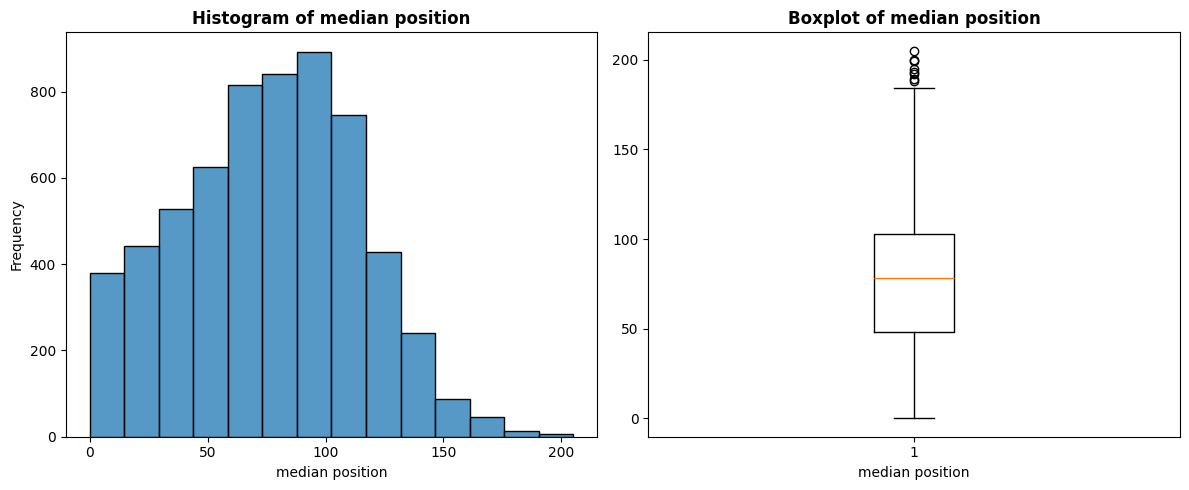

Outliers in median position: [np.int64(192), np.int64(193), np.int64(195), np.int64(199), np.int64(200), np.int64(205), np.int64(188), np.int64(189)]


,Name,Column,Lower Bound,Upper Bound,Outlier Value
5134,chris-barton,median position,0,185.5,205
5179,renan-ferraro,median position,0,185.5,188
5289,ramon-carretero,median position,0,185.5,192
5404,pedro-autran-dourado-dutra-nicacio,median position,0,185.5,193
5405,gabriel-machado-silva,median position,0,185.5,195
5477,sergio-jaramillo,median position,0,185.5,200
5674,rik-van-ijzendoorn,median position,0,185.5,189
5926,vadim-kravchenko,median position,0,185.5,199


Number of outliers in median position: 8


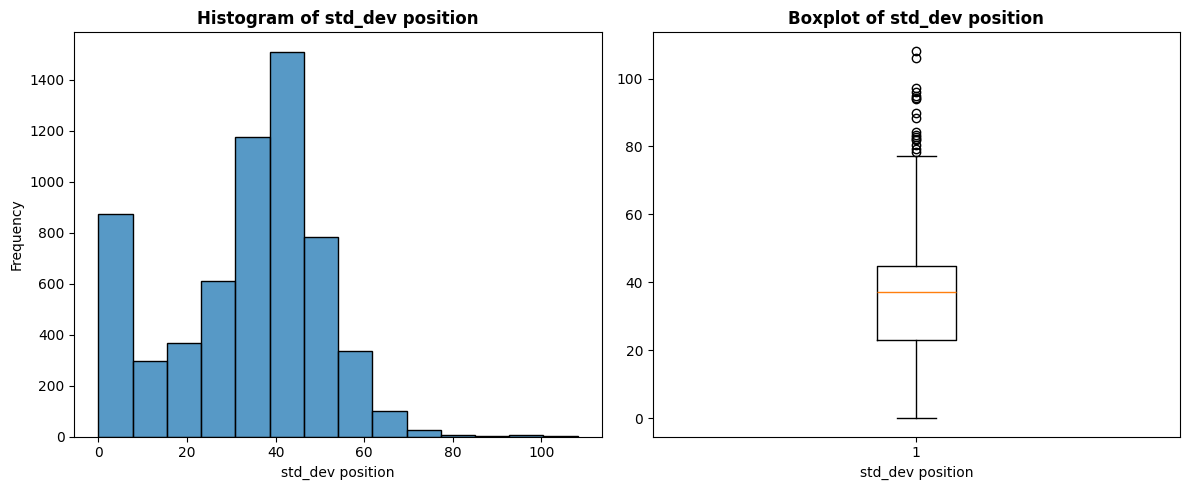

Outliers in std_dev position: [np.float64(96.16652224137046), np.float64(97.2745256135096), np.float64(106.06601717798212), np.float64(108.18733752154178), np.float64(78.48885271170677), np.float64(79.19595949289332), np.float64(80.49016503068351), np.float64(94.75230867899737), np.float64(81.94103571064582), np.float64(82.92365967161201), np.float64(84.11809879838313), np.float64(82.2455672564384), np.float64(83.43860018001261), np.float64(88.38834764831844), np.float64(89.77740329758454), np.float64(94.04520189781084), np.float64(94.40868604106298)]


,Name,Column,Lower Bound,Upper Bound,Outlier Value
2629,santiago-portillo-rosado,std_dev position,0.0,77.57,94.41
3820,lech-piasecki,std_dev position,0.0,77.57,84.12
3834,paul-watson,std_dev position,0.0,77.57,89.78
4432,nikolai-galitchanin,std_dev position,0.0,77.57,108.19
4905,sergei-sukhoruchenkov,std_dev position,0.0,77.57,97.27
5381,sylvain-bolay,std_dev position,0.0,77.57,94.75
5401,jose-inguanzo,std_dev position,0.0,77.57,106.07
5416,rustam-tukhvatulin,std_dev position,0.0,77.57,81.94
5430,michele-merlo,std_dev position,0.0,77.57,82.92
5475,pedro-jose-soler,std_dev position,0.0,77.57,79.20


Number of outliers in std_dev position: 17


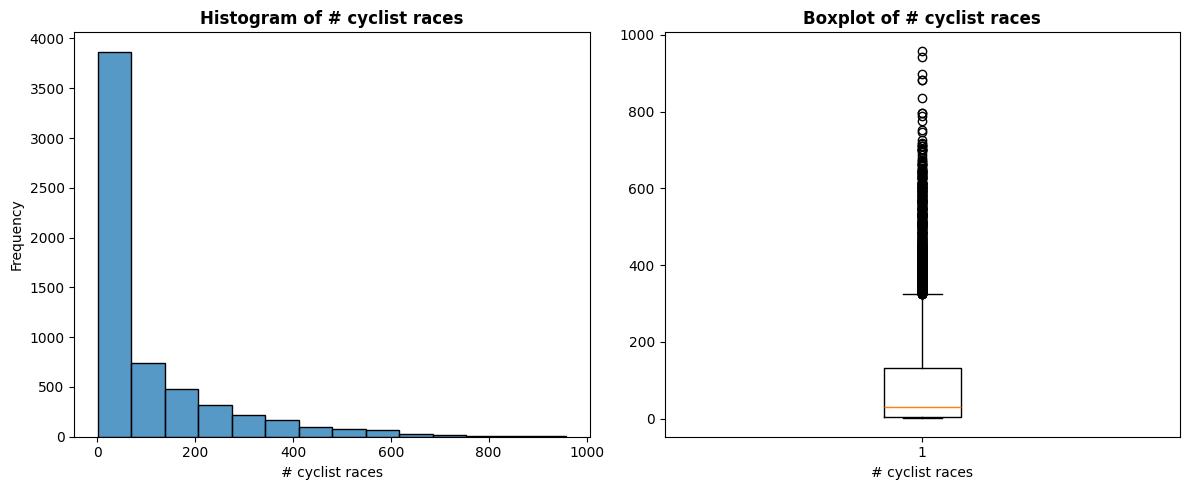

Outliers in # cyclist races: [np.int64(512), np.int64(513), np.int64(514), np.int64(515), np.int64(518), np.int64(519), np.int64(520), np.int64(522), np.int64(526), np.int64(527), np.int64(528), np.int64(529), np.int64(530), np.int64(531), np.int64(533), np.int64(534), np.int64(535), np.int64(537), np.int64(538), np.int64(544), np.int64(545), np.int64(546), np.int64(547), np.int64(549), np.int64(550), np.int64(552), np.int64(554), np.int64(556), np.int64(557), np.int64(559), np.int64(562), np.int64(563), np.int64(564), np.int64(565), np.int64(567), np.int64(568), np.int64(569), np.int64(570), np.int64(571), np.int64(574), np.int64(575), np.int64(576), np.int64(577), np.int64(581), np.int64(582), np.int64(583), np.int64(585), np.int64(587), np.int64(590), np.int64(591), np.int64(592), np.int64(594), np.int64(595), np.int64(597), np.int64(598), np.int64(600), np.int64(601), np.int64(603), np.int64(605), np.int64(606), np.int64(608), np.int64(609), np.int64(610), np.int64(612), np.int64(6

,Name,Column,Lower Bound,Upper Bound,Outlier Value
0,sean-kelly,# cyclist races,1,325.0,629
37,henk-lubberding,# cyclist races,1,325.0,346
56,joop-zoetemelk,# cyclist races,1,325.0,334
106,robert-gesink,# cyclist races,1,325.0,653
107,kenny-elissonde,# cyclist races,1,325.0,386
...,...,...,...,...,...
2701,marc-sergeant,# cyclist races,1,325.0,338
2708,steven-rooks,# cyclist races,1,325.0,332
2843,kim-kirchen,# cyclist races,1,325.0,329
2941,vladimir-gusev,# cyclist races,1,325.0,359


Number of outliers in # cyclist races: 530


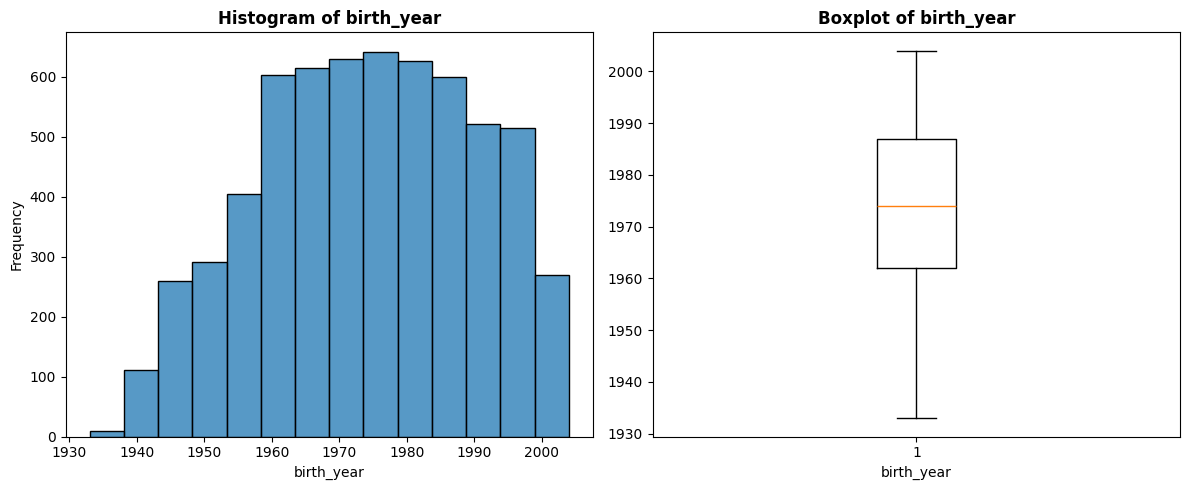

Outliers in birth_year: []
Number of outliers in birth_year: 0


In [2960]:
for column in numeric_columns:
    show_hist_and_box_plot(cyclists,column)
    bounds = calculate_outlier_bounds(cyclists, column)
    lower_bound = round(bounds['lower'], 2)
    upper_bound = round(bounds['upper'], 2)
    
    outliers_list = []
    outliers = cyclists[
        (cyclists[column] < lower_bound) | (cyclists[column] > upper_bound)
    ]

    column_outliers_count = len(outliers)

    column_outliers_df = pd.DataFrame({
        "Name": outliers['name'],
        "Column": column,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Value": outliers[column].round(2)
    })
    if(column_outliers_count > 0):
        display(column_outliers_df)
    print(f"Number of outliers in {column}: {column_outliers_count}")

In [2961]:
def check_all_outliers(df):

    # dataframe to keep track of outliers for each row
    outlier_flags = pd.DataFrame(index=df.index)

    for column in numeric_columns:
        bounds = calculate_outlier_bounds(df, column)
        lower_bound = bounds['lower']
        upper_bound = bounds['upper']
        
        # set rows with outliers for the current column
        outlier_flags[column] = (df[column] < lower_bound) | (df[column] > upper_bound)

    # count the number of column with outliers for each row
    outlier_flags['outlier_count'] = outlier_flags.sum(axis=1)

    # compute the percentage of columns with outliers for each row
    outlier_flags['outlier_percentage'] = (outlier_flags['outlier_count'] / len(numeric_columns)) * 100

    # rows with at least one outlier
    rows_with_outliers = outlier_flags[outlier_flags['outlier_count'] > 0]

    display(rows_with_outliers)

    print(f"Total number of rows: {len(df)}")
    print(f"Total rows with outliers: {len(rows_with_outliers)}")
    print(f"Percentage of rows with outliers: {(len(rows_with_outliers) / len(df)) * 100:.2f}%")

    return rows_with_outliers

In [2962]:
rows_with_outliers = check_all_outliers(numeric_cyclists_df)

,BMI,median position,std_dev position,# cyclist races,birth_year,outlier_count,outlier_percentage
0,False,False,False,True,False,1,20.0
14,True,False,False,False,False,1,20.0
27,True,False,False,False,False,1,20.0
37,False,False,False,True,False,1,20.0
56,False,False,False,True,False,1,20.0
...,...,...,...,...,...,...,...
5926,False,True,False,False,False,1,20.0
5971,False,False,True,False,False,1,20.0
6001,True,False,False,False,False,1,20.0
6085,True,False,False,False,False,1,20.0


Total number of rows: 6095
Total rows with outliers: 618
Percentage of rows with outliers: 10.14%


In [2963]:
rows_with_outliers[rows_with_outliers['outlier_count'] > 1]


,BMI,median position,std_dev position,# cyclist races,birth_year,outlier_count,outlier_percentage
241,True,False,False,True,False,2,40.0
565,True,False,False,True,False,2,40.0
1166,True,False,False,True,False,2,40.0


### Outliers elimination
For outlier elimination, we follow an approach that focuses on identifying the most extreme values by using intervals beyond the lower and upper bounds. This allows us to remove only the truly extreme outliers without significantly altering the distribution or the representativeness of the data. This way, we preserve the integrity of the dataset while addressing the issue of outliers effectively.


In [2964]:
def compare_box_plots(dataframe1, dataframe2, column_name):
    column1 = dataframe1[column_name]
    column2 = dataframe2[column_name]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Boxplot1
    boxplot_dict = axes[0].boxplot(column1[~np.isnan(column1)])  # Removes the NaNs to avoid problems
    axes[0].set_title(f'Boxplot before outliers cleaning', fontweight='bold')
    axes[0].set_xlabel(column1.name)

    # Boxplot2
    boxplot_dict = axes[1].boxplot(column2[~np.isnan(column2)])  # Removes the NaNs to avoid problems
    axes[1].set_title(f'Boxplot after outliers cleaning', fontweight='bold')
    axes[1].set_xlabel(column2.name)


    plt.tight_layout() 
    plt.show()


In [2965]:
def compare_distributions(dataframe1, dataframe2, column_name):
    column1 = dataframe1[column_name]
    column2 = dataframe2[column_name]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
   
    # Histogram1 
    sbn.histplot(column1, bins='sturges', ax=axes[0])
    axes[0].set_title(f'Histogram before outliers cleaning', fontweight='bold')
    axes[0].set_xlabel(column1.name) 
    axes[0].set_ylabel('Frequency')

    #Histogram2
    sbn.histplot(column2, bins='sturges', ax=axes[1])
    axes[1].set_title(f'Histogram after outliers cleaning', fontweight='bold')
    axes[1].set_xlabel(column2.name) 
    axes[1].set_ylabel('Frequency')


    plt.tight_layout() 
    plt.show()


In [2966]:
def compare_distributions_consistent(dataframe1, dataframe2, column_name):
    column1 = dataframe1[column_name]
    column2 = dataframe2[column_name]
    
    # Combine the two datasets and calculate shared bin edges
    combined_data = np.concatenate([column1, column2])
    bins = np.histogram_bin_edges(combined_data, bins='sturges')  # Using the same binning method for consistency
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Histogram 1
    sbn.histplot(column1, bins=bins, ax=axes[0])
    axes[0].set_title('Histogram before outliers cleaning', fontweight='bold')
    axes[0].set_xlabel(column1.name)
    axes[0].set_ylabel('Frequency')

    # Histogram 2
    sbn.histplot(column2, bins=bins, ax=axes[1])
    axes[1].set_title('Histogram after outliers cleaning', fontweight='bold')
    axes[1].set_xlabel(column2.name)
    axes[1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

In [2967]:
def analyze_outliers(dataframe, column, lower_bound, upper_bound, num_ranges_up, num_ranges_down, range_increment_up, range_increment_down):
    # Identifica gli outliers
    outliers = dataframe[
        (dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)
    ]
    
    outliers_values = outliers[column].round(2)

    outliers_above = outliers[outliers[column] > upper_bound]
    outliers_below = outliers[outliers[column] < lower_bound]

    print(f"Outliers above upper bound ({upper_bound}): {len(outliers_above)}")
    print(f"Outliers below lower bound ({lower_bound}): {len(outliers_below)}")

    total_outliers = len(outliers_values)
    print(f"Total outliers: {total_outliers}")

    # Intervalli sopra l'upper bound (se ci sono outliers sopra)
    if not outliers_above.empty:
        upper_ranges = [upper_bound + i * range_increment_up for i in range(num_ranges_up + 1)]

        upper_ranges_outliers_counts = []
        for i in range(len(upper_ranges) - 1):
            range_min = upper_ranges[i]
            range_max = upper_ranges[i + 1]
            count = len(outliers_values[
                (outliers_values >= range_min) &
                (outliers_values < range_max)
            ])
            upper_ranges_outliers_counts.append((range_min, range_max, count))
            print(f"Number of outliers in the range of [{range_min}, {range_max}]: {count}")
        
        outliers_above_last_range = len(outliers_values[outliers_values >= upper_ranges[-1]])
        print(f"Number of outliers > {upper_ranges[-1]}: {outliers_above_last_range}\n")
    else:
        print("No outliers above the upper bound.")
        upper_ranges_outliers_counts = []
        outliers_above_last_range = 0

    # Intervalli sotto il lower bound (se ci sono outliers sotto)
    if not outliers_below.empty:
        lower_ranges = [lower_bound - i * range_increment_down for i in range(num_ranges_down + 1)]

        lower_ranges_outliers_counts = []
        for i in range(len(lower_ranges) - 1):
            range_min = lower_ranges[i + 1]  # Range più piccolo
            range_max = lower_ranges[i]      # Range più grande
            count = len(outliers_values[
                (outliers_values < range_max) &
                (outliers_values >= range_min)
            ])
            lower_ranges_outliers_counts.append((range_min, range_max, count))
            print(f"Number of outliers in the range of [{range_min}, {range_max}]: {count}")
        
        outliers_below_last_range = len(outliers_values[outliers_values < lower_ranges[-1]])
        print(f"Number of outliers < {lower_ranges[-1]}: {outliers_below_last_range}")
    else:
        print("No outliers below the lower bound.")
        lower_ranges_outliers_counts = []
        outliers_below_last_range = 0

    # return {
    #     "total_outliers": total_outliers,
    #     "upper_ranges_counts": upper_ranges_outliers_counts,
    #     "outliers_above_last_range": outliers_above_last_range,
    #     "lower_ranges_counts": lower_ranges_outliers_counts,
    #     "outliers_below_last_range": outliers_below_last_range
    # }

#### _# cyclist races_ (530)
We evaluate different ranges of values (in increments of 200) above the upper bound, selecting a reasonable threshold beyond which outliers are considered extreme

In [2968]:
bound = calculate_outlier_bounds(cyclists, "# cyclist races")
lower_bound_n_cyclist_races = bound['lower']
upper_bound_n_cyclist_races = bound['upper']

In [2969]:
analyze_outliers(cyclists, "# cyclist races", lower_bound_n_cyclist_races, upper_bound_n_cyclist_races, 7, 7, 100, 100)

Outliers above upper bound (325.0): 530
Outliers below lower bound (1): 0
Total outliers: 530
Number of outliers in the range of [325.0, 425.0]: 249
Number of outliers in the range of [425.0, 525.0]: 128
Number of outliers in the range of [525.0, 625.0]: 97
Number of outliers in the range of [625.0, 725.0]: 43
Number of outliers in the range of [725.0, 825.0]: 7
Number of outliers in the range of [825.0, 925.0]: 4
Number of outliers in the range of [925.0, 1025.0]: 2
Number of outliers > 1025.0: 0

No outliers below the lower bound.


We choose a value between [525, 725], which provides a good compromise for removing a significant number of outliers without overly altering the initial distribution. A value of 600 appears to be the most appropriate.

In [2970]:
len(cyclists[cyclists['# cyclist races'] > 600])

73

For better statistical precision, we rely on a quartile value that is close to 600. It is about the 98nd percentile.

In [2971]:
upper_extreme_quantile = cyclists["# cyclist races"].quantile(0.98)
upper_extreme_quantile

np.float64(549.1199999999999)

In [2972]:
cleaned_cyclists_df = cyclists.copy()  

cleaned_cyclists_df = cleaned_cyclists_df[
    (cleaned_cyclists_df['# cyclist races'] <=  upper_extreme_quantile)
]

print(f"Remaining rows after removal: {len(cleaned_cyclists_df)}")
print(f"Removed rows: {len(cyclists) - len(cleaned_cyclists_df)}")

Remaining rows after removal: 5973
Removed rows: 122


As shown in the below distribution and box plot graphs for the _# cyclist races_ column, the cleaned data does not deviate significantly from the original values. The core structure and range of this column remain consistent, while the most extreme outliers (> 600) have been effectively removed. This ensures that the cleaning process focused specifically on this column without distorting its overall characteristics.

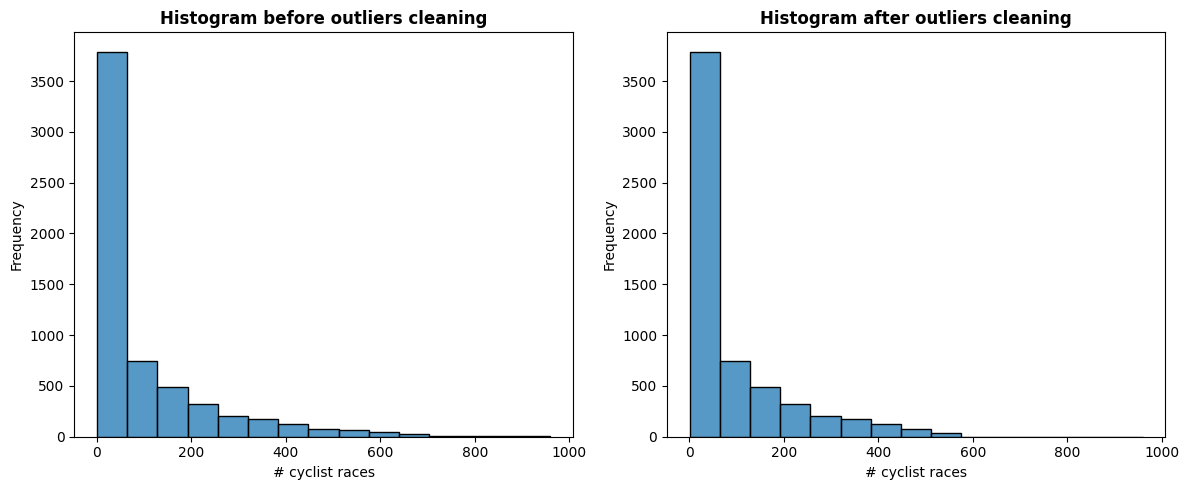

In [2973]:
compare_distributions_consistent(cyclists, cleaned_cyclists_df, "# cyclist races")

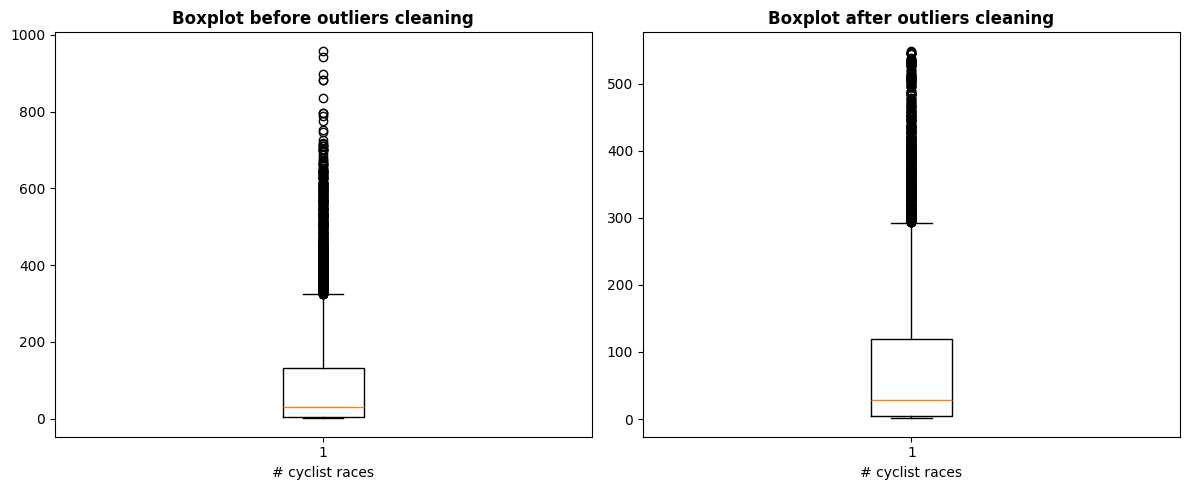

In [2974]:
compare_box_plots(cyclists, cleaned_cyclists_df, "# cyclist races")

In [2975]:
cleaned_cyclists_df
print(len(cyclists))
print(len(cleaned_cyclists_df))



6095
5973


#### BMI (66)


In [2976]:
bound = calculate_outlier_bounds(cyclists, "BMI")
lower_bound_BMI = bound['lower']
upper_bound_BMI = bound['upper']


In [2977]:
lower_bound_BMI

np.float64(17.639999999999997)

In [2978]:
upper_bound_BMI

np.float64(24.76)

In [2979]:
analyze_outliers(cyclists, "BMI", lower_bound_BMI, upper_bound_BMI, 4, 4, 0.5, 0.5)

Outliers above upper bound (24.76): 46
Outliers below lower bound (17.639999999999997): 20
Total outliers: 66
Number of outliers in the range of [24.76, 25.26]: 22
Number of outliers in the range of [25.26, 25.76]: 13
Number of outliers in the range of [25.76, 26.26]: 4
Number of outliers in the range of [26.26, 26.76]: 5
Number of outliers > 26.76: 2

Number of outliers in the range of [17.139999999999997, 17.639999999999997]: 14
Number of outliers in the range of [16.639999999999997, 17.139999999999997]: 3
Number of outliers in the range of [16.139999999999997, 16.639999999999997]: 3
Number of outliers in the range of [15.639999999999997, 16.139999999999997]: 0
Number of outliers < 15.639999999999997: 0


Let’s consider ‘extreme’ outliers as those below approximately 17.13 and above approximately 26.76. These thresholds correspond to the 0.092nd percentile  and the 99.98th percentile, respectively

In [2980]:
lower_extreme_quantile = cyclists["BMI"].quantile(0.00092)
upper_extreme_quantile = cyclists["BMI"].quantile(0.9998)
print(lower_extreme_quantile)
print(upper_extreme_quantile)

17.14734698346165
26.77343600000001


In [2981]:
len_before_cleaning = len(cleaned_cyclists_df)
cleaned_cyclists_df = cleaned_cyclists_df[
    (cleaned_cyclists_df['BMI'] <= upper_extreme_quantile) &
    (cleaned_cyclists_df['BMI'] >= lower_extreme_quantile)
]


print(f"Remaining rows after removal: {len(cleaned_cyclists_df)}")
print(f"Removed rows: {len_before_cleaning - len(cleaned_cyclists_df)}")


Remaining rows after removal: 5965
Removed rows: 8


As we can see, the distribution did not change much after removing the 8 most extreme outliers. Therefore, we expect this will not negatively impact the nature of the data.

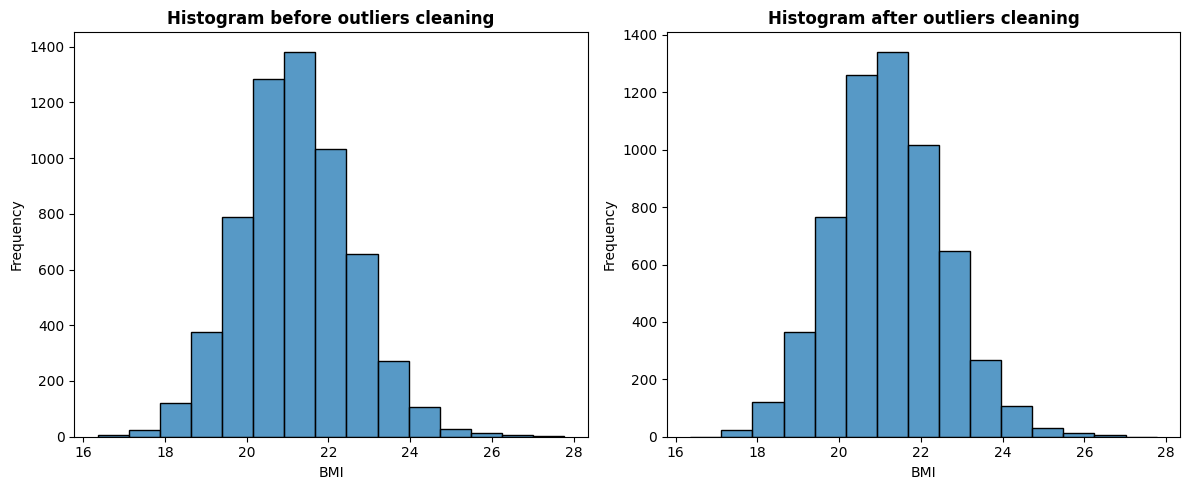

In [2982]:
compare_distributions_consistent(cyclists, cleaned_cyclists_df, "BMI")

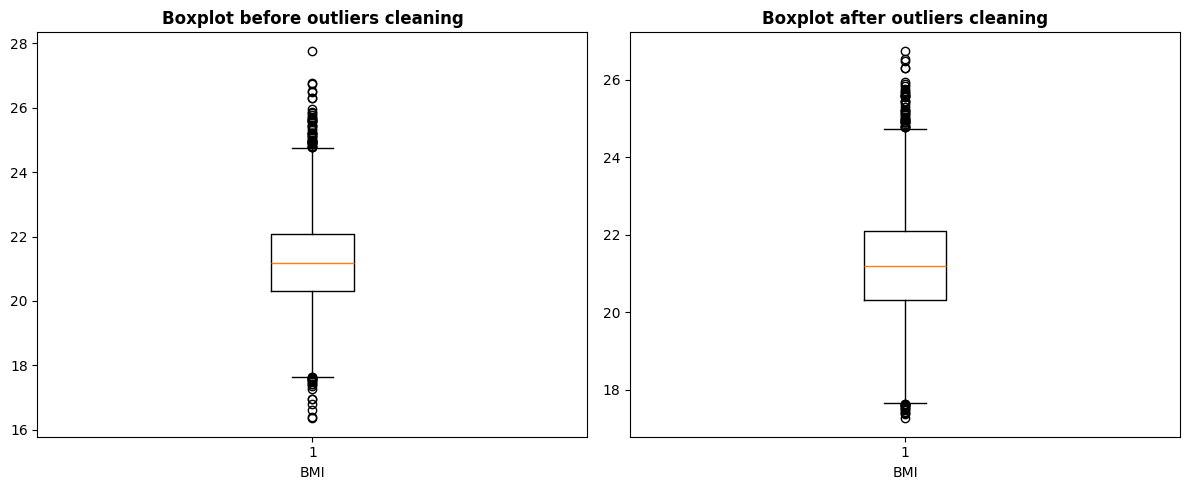

In [2983]:
compare_box_plots(cyclists,cleaned_cyclists_df, "BMI")

#### std_dev position (17)

In [2984]:
bound = calculate_outlier_bounds(cyclists, "std_dev position")
lower_bound_stdPos= bound['lower']
upper_bound_stdPos = bound['upper']


In [2985]:
analyze_outliers(cyclists, "std_dev position", lower_bound_stdPos, upper_bound_stdPos, 6, 6, 5, 5)

Outliers above upper bound (77.56711891904379): 17
Outliers below lower bound (0.0): 0
Total outliers: 17
Number of outliers in the range of [77.56711891904379, 82.56711891904379]: 5
Number of outliers in the range of [82.56711891904379, 87.56711891904379]: 3
Number of outliers in the range of [87.56711891904379, 92.56711891904379]: 2
Number of outliers in the range of [92.56711891904379, 97.56711891904379]: 5
Number of outliers in the range of [97.56711891904379, 102.56711891904379]: 0
Number of outliers in the range of [102.56711891904379, 107.56711891904379]: 1
Number of outliers > 107.56711891904379: 1

No outliers below the lower bound.


Let’s consider ‘extreme’ outliers as those above approximately 97.56, so the two most extreme ones. These thresholds correspond to the 99.97nd percentile.

In [2986]:
upper_extreme_quantile = cyclists["std_dev position"].quantile(0.9997)
upper_extreme_quantile

np.float64(98.78490386428663)

In [2987]:
len_before_cleaning = len(cleaned_cyclists_df)
cleaned_cyclists_df = cleaned_cyclists_df[(cleaned_cyclists_df['std_dev position'] <= upper_extreme_quantile)]

print(f"Remaining rows after removal: {len(cleaned_cyclists_df)}")
print(f"Removed rows: {len_before_cleaning - len(cleaned_cyclists_df)}")

Remaining rows after removal: 5963
Removed rows: 2


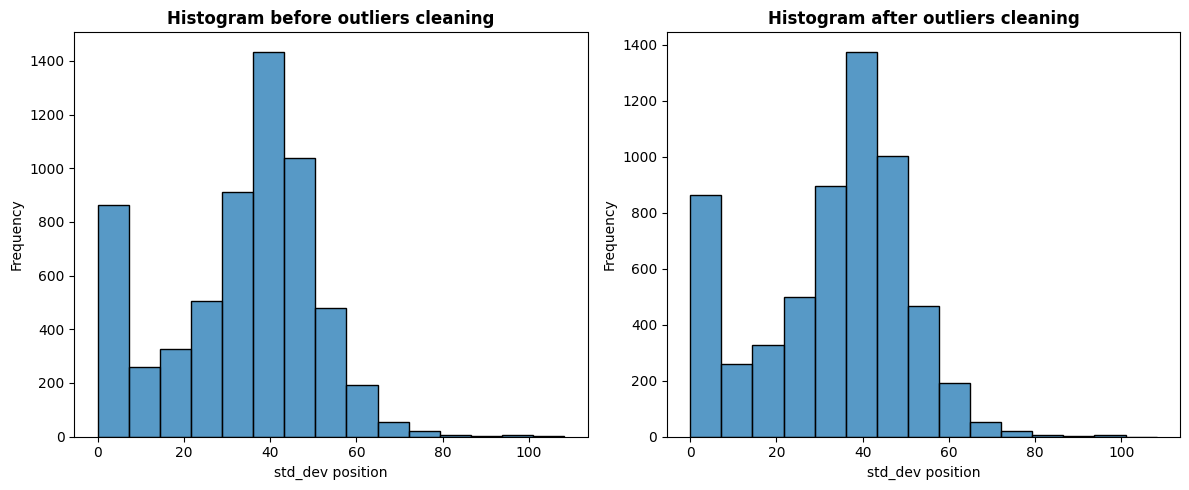

In [2988]:
compare_distributions_consistent(cyclists, cleaned_cyclists_df, "std_dev position")

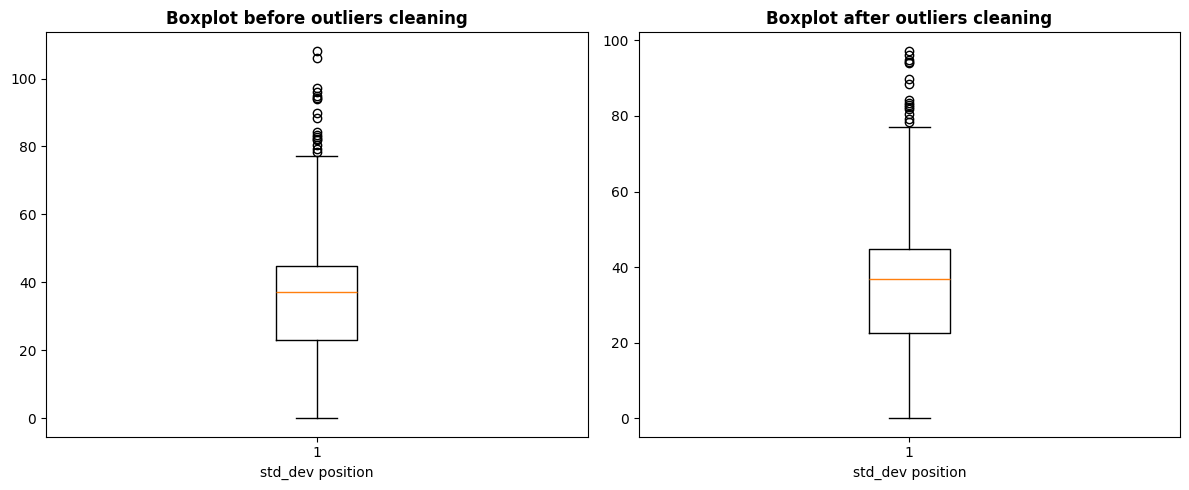

In [2989]:
compare_box_plots(cyclists, cleaned_cyclists_df, "std_dev position",)

#### median position (8)

In [2990]:
bound = calculate_outlier_bounds(cyclists, "median position")
lower_bound_medianPos = bound['lower']
upper_bound_medianPos = bound['upper']

In [2991]:
print(lower_bound_medianPos)
print(upper_bound_medianPos)

0
185.5


In [2992]:
analyze_outliers(cyclists, "median position", lower_bound_medianPos, upper_bound_medianPos, 6, 6, 5, 5)

Outliers above upper bound (185.5): 8
Outliers below lower bound (0): 0
Total outliers: 8
Number of outliers in the range of [185.5, 190.5]: 2
Number of outliers in the range of [190.5, 195.5]: 3
Number of outliers in the range of [195.5, 200.5]: 2
Number of outliers in the range of [200.5, 205.5]: 1
Number of outliers in the range of [205.5, 210.5]: 0
Number of outliers in the range of [210.5, 215.5]: 0
Number of outliers > 215.5: 0

No outliers below the lower bound.


Since there are no outliers that can be considered much more extreme than others, we try to eliminate all outliers and test the resulting distribution.

In [2993]:
len_before_cleaning = len(cleaned_cyclists_df)
cleaned_cyclists_df = cleaned_cyclists_df[
        (cleaned_cyclists_df["median position"] >= lower_bound_medianPos) & (cleaned_cyclists_df["median position"] <= upper_bound_medianPos)
    ]

print(f"Remaining rows after removal: {len(cleaned_cyclists_df)}")
print(f"Removed rows: {len_before_cleaning - len(cleaned_cyclists_df)}")

Remaining rows after removal: 5955
Removed rows: 8


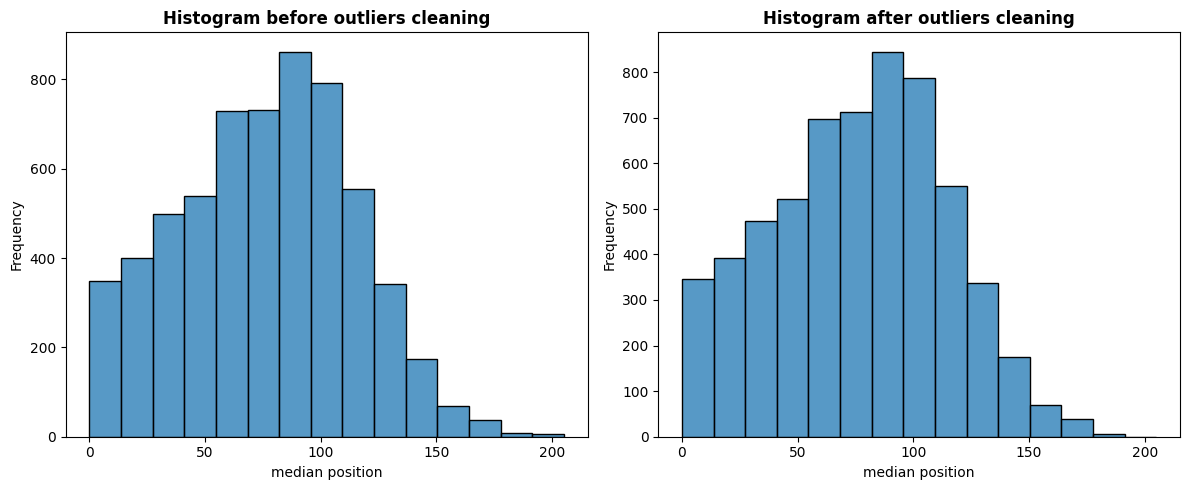

In [2994]:
compare_distributions_consistent(cyclists, cleaned_cyclists_df, "median position")

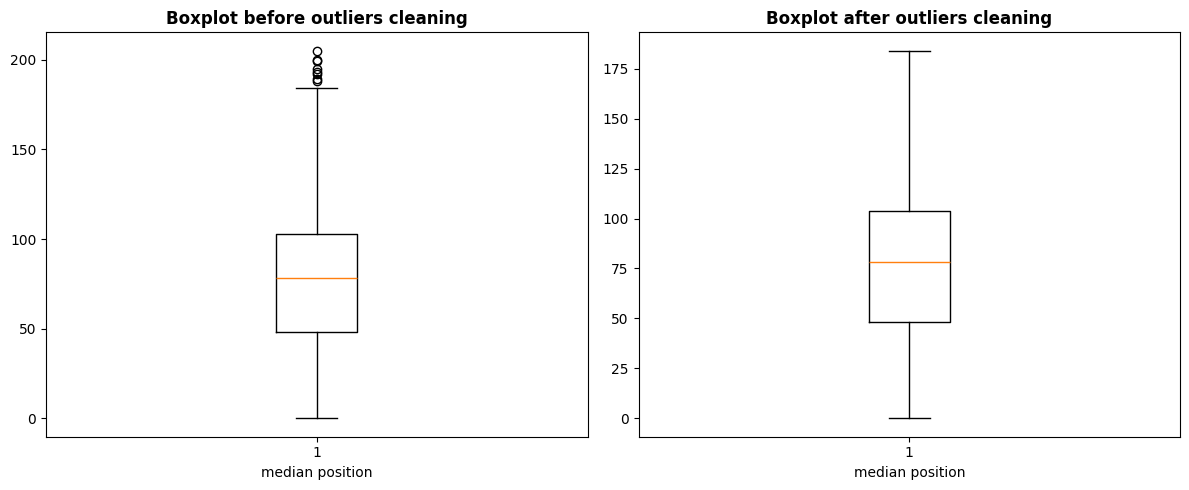

In [2995]:
compare_box_plots(cyclists, cleaned_cyclists_df, "median position")

As can be seen from the box plots and distributions above, removing all outliers has not significantly altered the nature of the data.

## Data normalization

In [2996]:
from sklearn.preprocessing import StandardScaler

def standardize_fun(df):
    scaler = StandardScaler()
    scaler.fit(df)
    X = scaler.transform(df)
    standardized_df = pd.DataFrame(X, columns=df.columns, index=df.index)
    print(standardized_df)
    
    standardizer = {"scaler": scaler, "standardized_df": standardized_df}

    return standardizer
   


In [2997]:
cyclists = cleaned_cyclists_df
len(cyclists)

5955

In [2998]:
numeric_cyclists_df = cyclists[numeric_columns]
numeric_cyclists_df

,BMI,median position,std_dev position,# cyclist races,birth_year
1,19.959003,38,46.993017,271,1951.0
2,22.790000,42,32.648452,146,1954.0
3,23.086015,8,19.723611,48,1948.0
4,21.300000,25,26.276978,145,1951.0
5,20.916803,7,34.928320,62,1948.0
...,...,...,...,...,...
6090,19.696783,173,0.000000,1,1969.0
6091,20.031931,17,0.000000,1,1965.0
6092,25.450000,54,0.000000,1,1992.0
6093,20.011635,38,0.000000,1,1948.0


In [2999]:
standardizer = standardize_fun(numeric_cyclists_df)
standardized_cyclists_df = standardizer['standardized_df']

           BMI  median position  std_dev position  # cyclist races  birth_year
1    -0.933289        -1.016874          0.799777         1.563687   -1.462154
2     1.167189        -0.910558         -0.009832         0.507560   -1.270509
3     1.386820        -1.814251         -0.739312        -0.320444   -1.653798
4     0.061673        -1.362404         -0.369439         0.499111   -1.462154
5    -0.222643        -1.840830          0.118844        -0.202158   -1.653798
...        ...              ...               ...              ...         ...
6090 -1.127846         2.571318         -1.852516        -0.717548   -0.312285
6091 -0.879180        -1.575038         -1.852516        -0.717548   -0.567811
6092  3.140796        -0.591607         -1.852516        -0.717548    1.156992
6093 -0.894239        -1.016874         -1.852516        -0.717548   -1.653798
6094  1.493976        -0.405553         -1.852516        -0.717548   -1.398272

[5955 rows x 5 columns]


## PCA
We apply Principal Component Analysis (PCA) to the standardized dataset (standardized_cyclists_df) to reduce its dimensionality while preserving 90% of the variance. It calculates the number of principal components required to achieve this variance threshold and transforms the dataset into the PCA-reduced space

In [3000]:
# Try to apply PCA to get the optimal number of components
pca_instance = PCA(n_components=0.90)  # Preserve 90% of the variance
pca_std_numeric_cyclists = pca_instance.fit_transform(standardized_cyclists_df)

print(f"# selected principal components: {pca_instance.n_components_}")

# selected principal components: 4


In [3001]:
# pca = PCA()
# pca.fit(X) 

# # Compute the contribution (loadings) of each feature to each principal component
# loadings = pd.DataFrame(
#     pca.components_.T, # Transpose to align features with components
#     columns=[f'PC{i+1}' for i in range(pca.n_components_)], # Label columns as PC1, PC2, etc.
#     index=numeric_cyclists_df.columns # Use feature names as index
# )

# display(loadings)

# # Calculate the importance of each feature based on the first two principal components
# top_components = loadings.iloc[:, :2].abs().sum(axis=1) 
# top_variables = top_components.sort_values(ascending=False)


# print("\nFeatures sorted by contribution:")
# print(top_variables)


# selected_columns = top_variables.index.tolist()
# print(f"\nSelected columns: {selected_columns}")


In [3002]:
pca_std_numeric_cyclists

array([[-0.34956381,  2.03816271, -1.40192112,  0.73325803],
       [-1.11512137,  1.48753928,  0.75144621, -0.01285046],
       [-2.48880771,  1.23476398,  0.88103493, -0.1422566 ],
       ...,
       [-1.0773674 , -0.43653015,  2.66131075, -2.48289351],
       [-2.6380196 , -0.48055358, -0.95833783,  0.02827371],
       [-2.33549507, -0.16649217,  1.38075703, -0.66367382]])

## Kmeans grid search

In [3003]:
def kmeans_grid_search(df):
    results = []  # used to save sse and silhouette for each k
    previous_sse = None

    for k in range(2,16):
        kmeans = KMeans(n_clusters=k, max_iter=300, random_state=42)
        labels = kmeans.fit_predict(df)
        sse = kmeans.inertia_  # Calcola il SSE
        silhouette_avg = silhouette_score(df, labels) 

        if previous_sse is not None:
            sse_reduction_percentage = ((previous_sse - sse) / previous_sse) * 100
            print(f"k: {k} -> silhouette: {silhouette_avg}, sse: {sse}, sse reduction: {sse_reduction_percentage:.2f}%")
        else:
            print(f"k: {k} -> silhouette: {silhouette_avg}, sse: {sse}")
    
        # Salva i risultati
        results.append({"k": k, "sse": sse, "silhouette": silhouette_avg})
        previous_sse = sse
   
    return results

In [3004]:
def k_means_evaluation_plotting(results):

    print(results)
    k_values = [result["k"] for result in results]
    sse_values = [result["sse"] for result in results]
    silhouette_values = [result["silhouette"] for result in results]

    plt.figure()
    plt.plot(k_values, sse_values, marker='o', label='SSE')
    plt.title('SSE with Elbow method')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('SSE')
    plt.show()

    plt.figure()
    plt.plot(k_values, silhouette_values, marker='o', label='Silhouette Score', color='orange')
    plt.title('Silhouette Score')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.show()

In [3005]:
def get_best_k(results):
    best_result = max(results, key=lambda x: x["silhouette"])

    best_k = best_result["k"]
    return best_k

In [3006]:
# # Configurazione dei parametri per il Grid Search
# k_values = range(2, 11)
# param_grid = {
#     'n_clusters': k_values,
# }

# # Creazione del modello KMeans
# kmeans = KMeans(random_state=42)

# # Variabili per tracciare i migliori risultati
# best_combined_score = -float('inf')
# best_combined_params = {}

# # Liste per normalizzazione
# sse_all = []
# silhouette_all = []
# separation_all = []
# param_list = []

# # Itera sui parametri
# for n_clusters in param_grid['n_clusters']:

#     kmeans = KMeans(n_clusters=n_clusters, random_state=42, init='k-means++', max_iter=300)
    
#     labels = kmeans.fit_predict(X)
#     silhouette = silhouette_score(X, labels)
#     sse = kmeans.inertia_
#     separation = davies_bouldin_score(X, labels)

#     # Aggiungi ai valori globali per normalizzare successivamente
#     sse_all.append(sse)
#     silhouette_all.append(silhouette)
#     separation_all.append(separation)
#     param_list.append({'n_clusters': n_clusters, 'max_iter': 300})  # Salva i parametri associati

#     print(f"n_clusters: {n_clusters}, max_iter: {300} -> SSE: {sse}, Davies-Bouldin: {separation}, Silhouette: {silhouette}")

# # Normalizza le metriche
# sse_min, sse_max = min(sse_all), max(sse_all)
# silhouette_min, silhouette_max = min(silhouette_all), max(silhouette_all)
# separation_min, separation_max = min(separation_all), max(separation_all)

# sse_norm = [(sse_max - sse) / (sse_max - sse_min) for sse in sse_all]
# silhouette_norm = [(silhouette - silhouette_min) / (silhouette_max - silhouette_min) for silhouette in silhouette_all]
# separation_norm = [(separation_max - sep) / (separation_max - separation_min) for sep in separation_all]

# # Ricalcola il punteggio combinato
# for i, (sse, silhouette, separation) in enumerate(zip(sse_norm, silhouette_norm, separation_norm)):
#     combined_score = (silhouette + sse + separation) / 3  # Media pesata
#     if combined_score > best_combined_score:
#         best_combined_score = combined_score
#         best_combined_params = {'n_clusters': param_list[i]['n_clusters'],
#             'max_iter': param_list[i]['max_iter'],'index': i, 'sse': sse, 'silhouette': silhouette, 'separation': separation}

# # Risultati
# print("\nMiglior punteggio combinato:", best_combined_score)
# print("Parametri associati:", best_combined_params)

In [3007]:
# # Crea il grafico della distribuzione dei punti nei cluster (scatter plot)
# plt.figure(figsize=(10, 6))
# sbn.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels, palette="Set2", s=50, alpha=0.7)
# plt.title(f'Cluster con {best_params["n_clusters"]} cluster', fontsize=14)
# plt.xlabel('Feature 1', fontsize=12)
# plt.ylabel('Feature 2', fontsize=12)
# plt.show()

# # Calcola la silhouette score per ogni punto
# silhouette_vals = silhouette_samples(X, labels)

# # Crea un grafico della silhouette score per ogni punto
# plt.figure(figsize=(10, 6))
# sbn.histplot(silhouette_vals, kde=True, color="skyblue", bins=50)
# plt.title(f'Punteggio Silhouette per {best_params["n_clusters"]} cluster', fontsize=14)
# plt.xlabel('Silhouette Score', fontsize=12)
# plt.ylabel('Frequenza', fontsize=12)
# plt.show()

In [3008]:
results = kmeans_grid_search(pca_std_numeric_cyclists)

k: 2 -> silhouette: 0.2837349106368867, sse: 19671.28164379123
k: 3 -> silhouette: 0.28171711397061683, sse: 15412.846817790334, sse reduction: 21.65%
k: 4 -> silhouette: 0.257503897513941, sse: 12985.707608973273, sse reduction: 15.75%
k: 5 -> silhouette: 0.24975695940082465, sse: 11481.25152469725, sse reduction: 11.59%
k: 6 -> silhouette: 0.24520918814214157, sse: 10178.105161536561, sse reduction: 11.35%
k: 7 -> silhouette: 0.23283130213025155, sse: 9639.235368571884, sse reduction: 5.29%
k: 8 -> silhouette: 0.22940309632612155, sse: 8721.967865673698, sse reduction: 9.52%
k: 9 -> silhouette: 0.21986717947218792, sse: 8259.748418000701, sse reduction: 5.30%
k: 10 -> silhouette: 0.21213322568669402, sse: 7813.744566831496, sse reduction: 5.40%
k: 11 -> silhouette: 0.2087463014370653, sse: 7427.345731018798, sse reduction: 4.95%
k: 12 -> silhouette: 0.20887244021381515, sse: 7086.457280355037, sse reduction: 4.59%
k: 13 -> silhouette: 0.19875614609643127, sse: 6898.823525563203, sse 

[{'k': 2, 'sse': 19671.28164379123, 'silhouette': np.float64(0.2837349106368867)}, {'k': 3, 'sse': 15412.846817790334, 'silhouette': np.float64(0.28171711397061683)}, {'k': 4, 'sse': 12985.707608973273, 'silhouette': np.float64(0.257503897513941)}, {'k': 5, 'sse': 11481.25152469725, 'silhouette': np.float64(0.24975695940082465)}, {'k': 6, 'sse': 10178.105161536561, 'silhouette': np.float64(0.24520918814214157)}, {'k': 7, 'sse': 9639.235368571884, 'silhouette': np.float64(0.23283130213025155)}, {'k': 8, 'sse': 8721.967865673698, 'silhouette': np.float64(0.22940309632612155)}, {'k': 9, 'sse': 8259.748418000701, 'silhouette': np.float64(0.21986717947218792)}, {'k': 10, 'sse': 7813.744566831496, 'silhouette': np.float64(0.21213322568669402)}, {'k': 11, 'sse': 7427.345731018798, 'silhouette': np.float64(0.2087463014370653)}, {'k': 12, 'sse': 7086.457280355037, 'silhouette': np.float64(0.20887244021381515)}, {'k': 13, 'sse': 6898.823525563203, 'silhouette': np.float64(0.19875614609643127)}, 

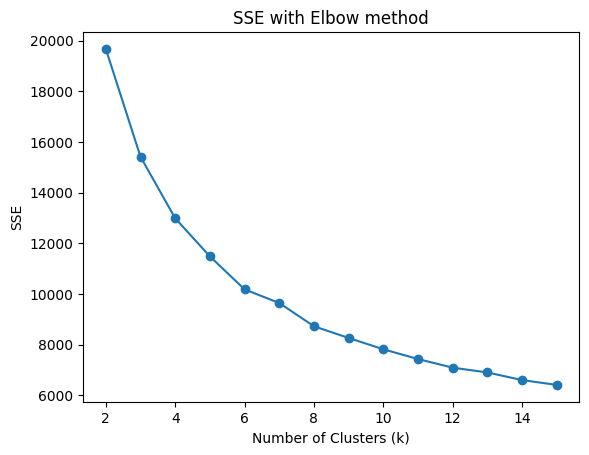

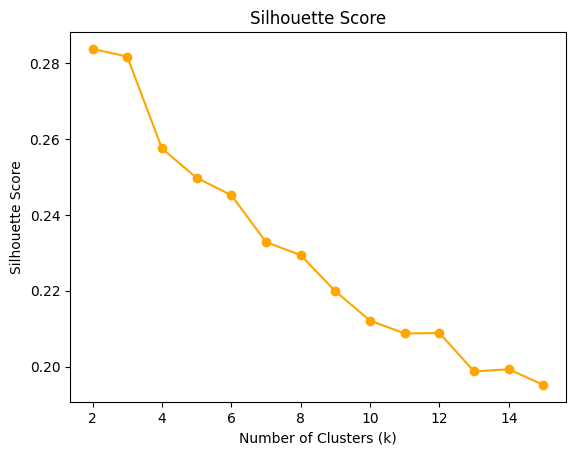

In [3009]:
k_means_evaluation_plotting(results)

## Compute Kmeans algorithm with best K found
Analyzing the Elbow Method of SSE and the Silhouette Score, the optimal  k  values do not align. The Silhouette Score suggests  k = 2  as the optimal number of clusters, while the SSE indicates  k = 5  or  k = 6 . As a trade-off, we choose  k = 4 .

In [3010]:
def kmeans_run(data, best_k, scaler):
    scaler = standardizer['scaler']
    print(f"\nBest k based on a trade-off between silhuoette score and sse: {best_k}")

    # best kmeans with best clusters number
    best_kmeans = KMeans(n_clusters=best_k, random_state=42, init='k-means++', max_iter=300)

    best_kmeans.fit(data)
    print(f"k: {best_k}, Number of iterations: {best_kmeans.n_iter_}")

    centers = best_kmeans.cluster_centers_

    # Trasforma i centroidi dallo spazio PCA a quello standardizzato
    centers_standardized = pca_instance.inverse_transform(centers)

    # Inverso della trasformazione per ottenere i centroidi nello spazio originale (non normalizzato)
    centers_original_space = scaler.inverse_transform(centers_standardized)

    print("Centroids")
    print(centers_original_space)

    kmeans_data = {"best_kmeans": best_kmeans, "centroids": centers_original_space}

    return kmeans_data

  



In [3011]:
kmeans_data = kmeans_run(data=pca_std_numeric_cyclists, best_k=4, scaler=standardizer['scaler'])
best_kmeans = kmeans_data['best_kmeans']
centroids = kmeans_data['centroids']


Best k based on a trade-off between silhuoette score and sse: 4
k: 4, Number of iterations: 11
Centroids
[[  20.94884911   59.91241468   44.32571579  294.29959499 1981.22013319]
 [  20.54260068  102.91353931   28.66011261   38.93422771 1986.01942209]
 [  22.05016545   91.47887253   46.24838042   74.81567317 1971.28352836]
 [  21.31245481   35.01335444   14.7625842    17.16481658 1956.05627055]]


In [3012]:
# count points for each cluster
cluster_counts = pd.Series(best_kmeans.labels_).value_counts().sort_index()

print("Number of points for each cluster")
print(cluster_counts)

Number of points for each cluster
0     984
1    1873
2    1664
3    1434
Name: count, dtype: int64


Let's print a summary of the average values for each feature within the clusters

In [3013]:
numeric_cyclists_df = numeric_cyclists_df.copy() 
# Add Cluster as a column to the dataset
numeric_cyclists_df['Cluster'] = best_kmeans.labels_

# Compute statistics for each feature grouped by cluster
detailed_cluster_stats = numeric_cyclists_df.groupby('Cluster').agg(['mean', 'median', 'min', 'max'])

detailed_cluster_stats.columns = ['_'.join(col) for col in detailed_cluster_stats.columns]

display(detailed_cluster_stats)

,BMI_mean,BMI_median,BMI_min,BMI_max,median position_mean,median position_median,median position_min,median position_max,std_dev position_mean,std_dev position_median,std_dev position_min,std_dev position_max,# cyclist races_mean,# cyclist races_median,# cyclist races_min,# cyclist races_max,birth_year_mean,birth_year_median,birth_year_min,birth_year_max
Cluster,,,,,,,,,,,,,,,,,,,,
0,20.915235,20.900000,17.412666,25.310000,66.799797,67.0,8,131,42.622679,42.148645,18.713423,72.428232,308.294715,295.0,92,549,1978.840447,1979.0,1946.0,2000.0
1,20.548025,20.570000,17.263427,24.432154,101.155366,101.0,9,184,29.157312,33.270150,0.000000,65.760931,35.456487,17.0,1,220,1986.616658,1988.0,1951.0,2004.0
2,22.069447,22.040000,18.833727,26.750000,89.225962,90.0,4,178,46.725342,45.960965,0.000000,97.274526,70.152043,49.0,1,358,1972.079327,1971.0,1940.0,2002.0
3,21.308165,21.283847,17.486589,26.530000,35.182008,31.0,0,143,14.752854,13.034675,0.000000,58.149592,17.565551,4.0,1,267,1955.965132,1955.0,1933.0,1992.0


## Distribution of points for each feature across clusters

In [3014]:
def clusters_box_plot(df):

    columns = [col for col in df.columns if col != 'Cluster']
    n_rows = (len(columns) + 2 - 1) // 2  

    fig, axes = plt.subplots(n_rows, 2, figsize=(14, 5 * n_rows), sharey=False)

    # Rendi axes un array 1D per un accesso più semplice
    axes = axes.flatten()

    for i, column in enumerate(columns):
        sbn.boxplot(x='Cluster', y=column, data=df, ax=axes[i])
        axes[i].set_title(f"Distribution of '{column}'")
        axes[i].set_xlabel("Cluster")
        axes[i].set_ylabel(column)

    # Nascondi subplot extra (se presenti)
    for j in range(len(columns), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

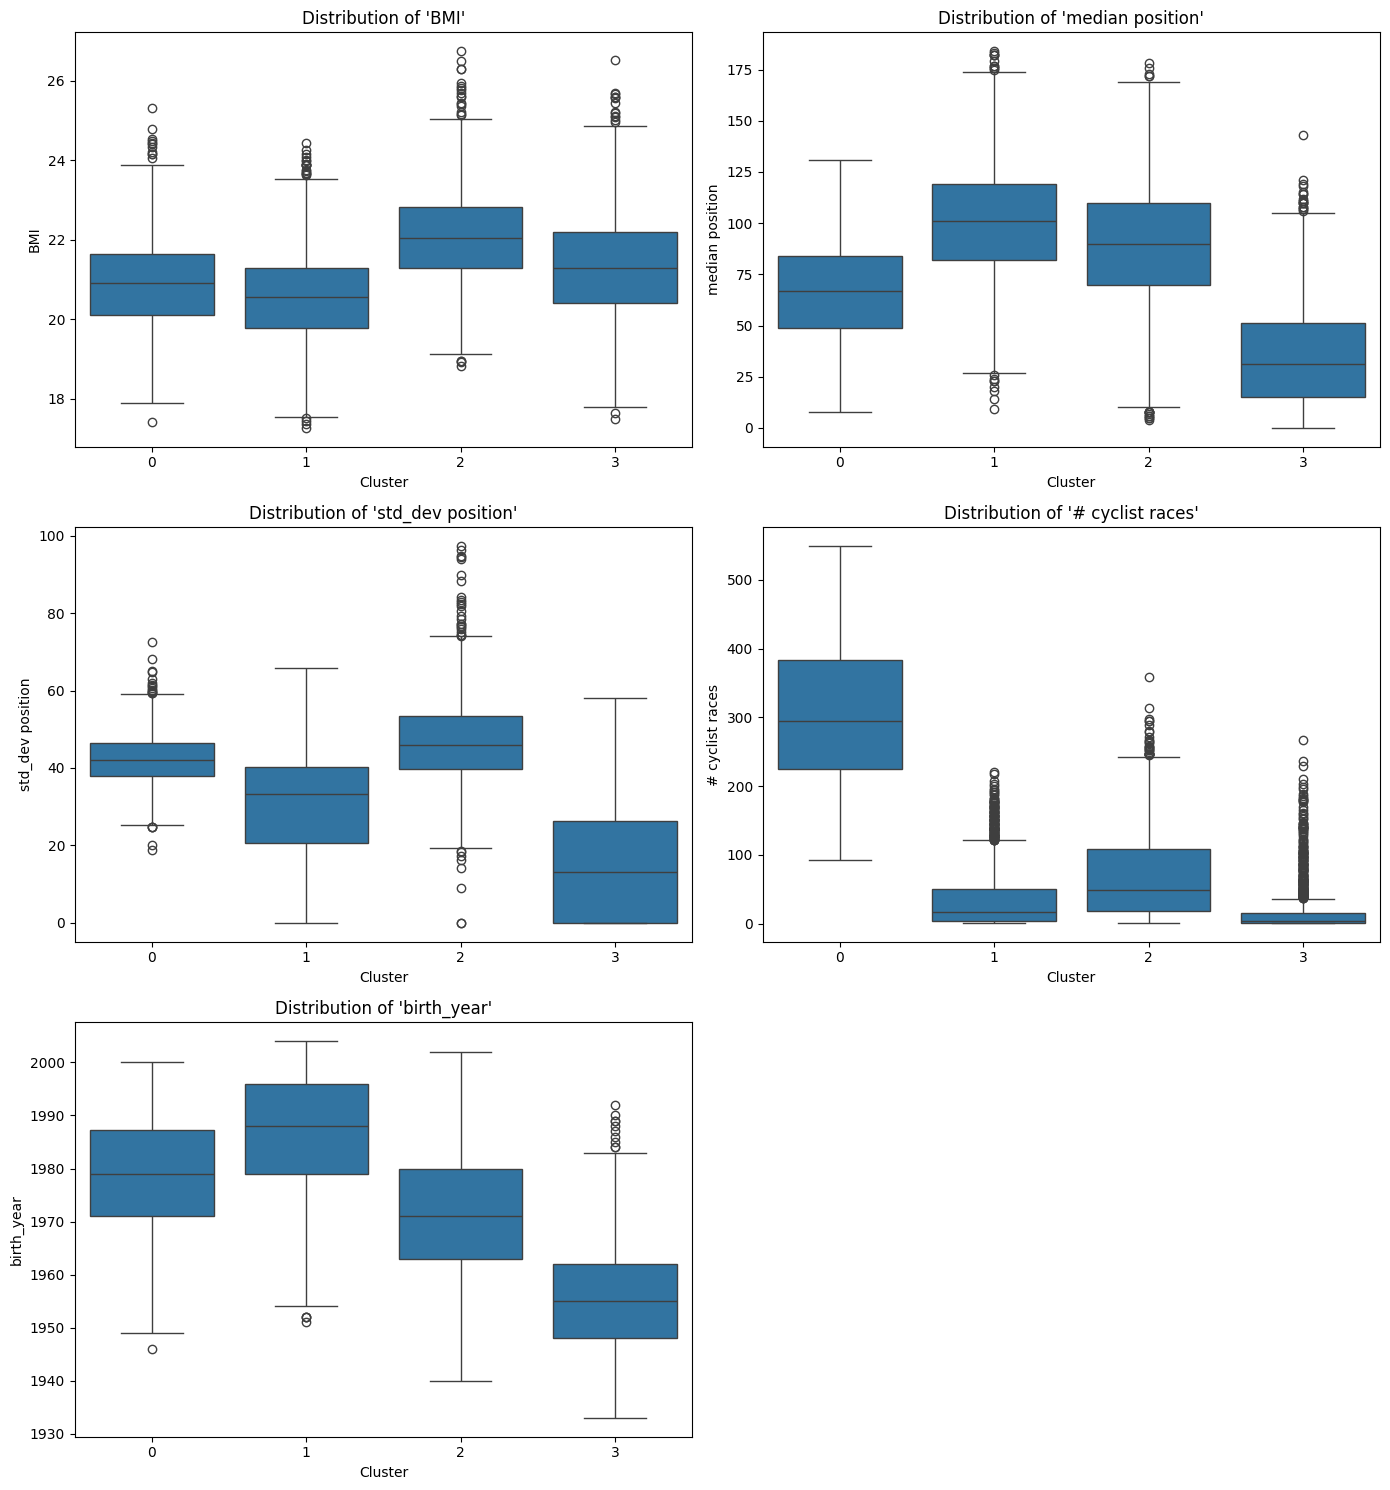

In [3015]:
clusters_box_plot(numeric_cyclists_df)

### Box-plots analysis

By analying the box-plots above, we can try to analyze the 4 clusters by considering points distribution for each feature:
- **Cluster 0** (984 points): 

  - **_BMI_**: values are centered around a median of 21, with a moderately tight interquartile range. There are some outliers on both the lower and upper ends, with the lowest BMI slightly above 18 and the highest below 26.
  
  - **_median position_**: this cluster has a wide enough IQR for the median position, but the narrowest among all other clusters, with values ranging from ~50 to ~90. The median is approximately 70. There are no outliers.

  - **_# cyclist races_**: cyclists in this cluster participated in the largest number of races with a median of 300. IQR is the widest and spreads from ~220 to ~380. There are no outliers.
  
  - **_birth\_year_**: this cluster has a median birth year around 1980, with an IQR ranging from ~1971 to ~ 1988. There are one or a few outliers below 1950.

  - **_std\_dev position_**: the median standard deviation of position is around 42 and IQR is the narrowest. This cluster has a lot of outliers on both the lower and the upper ends, below 20 and beyond 65.

- **Cluster 1** (1873 points): 

  - **_BMI_**: the median BMI is approximately 21, and outliers are present on both ends. The IQR depth is quite similar to that of Cluster 0, but with slighlty lower values.
  
  - **_median position_**: the median position is the highest compared to the other clusters. The median values is around 100 and there are many high-end outliers over 175, and many low-end outliers close to 5.

  - **_# cyclist races_**: the distribution shows a tighter IQR and a lower median, around 15. There are many high-end outliers, with values over 200.
  
  - **_birth\_year_**: the median birth year is ~1990, the highest compared to the other clusters. Outliers are present just above the ~1950s.

  - **_std\_dev position_**: the median std deviation of position is around 30 and the IQR ranges from ~20 to ~40. There are not outliers.

- **Cluster 2** (1664 points): 

  - **_BMI_**: the median BMI is around 22, the highest. There are many outliers up to over 26, and some around 19.
  
  - **_median position_**: this cluster has the widest IQR compared to the others, with a median position around ~90. There are some high-end and low-end outliers.

  - **_# cyclist races_**: the median of number of races in this cluster is about 50 and also contains a significant number of high-end outliers, the highest just below 400.
  
  - **_birth\_year_**: IQR here, ranges from ~1965 to ~1980 and the median value is approximately 1971. There are no outliers.

  - **_std\_dev position_**: this cluster has the highest median standard deviation of position, around 45. The are a lot of high-end outliers up to 100, and a lot of low-end outliers down to 0.

- **Cluster 3** (1434 points): 

  - **_BMI_**: median is about ~21 and the IQR is the slightly widest. There are few low-end outliers and many other high-end ones.
  
  - **_median position_**: the median position is the smallest here, about ~30, with some outliers on the upper end up to ~150.

  - **_# cyclist races_**: cyclists in this cluster have the smallest number of races, with a median around 15 and the tightest IQR. There are a lot of outliers on the upper part, up to about ~300
  
  - **_birth\_year_**: this cluster has the cyclists born in more distant years, with a median around 1955. Some outliers extend to earlier years, up to 1990s.

  - **_std\_dev position_**: this cluster has the smallest median standard deviation of position, ~15, but the widest IQR, ranging from ~0 to ~30, suggesting more consistency in performance. There are no outliers.




 

Based on the analysis provided, here’s what we can infer about the clusters:
#### Cluster 0
Cluster 0 could represent highly experienced cyclists with a median of ~300 races, the highest among all clusters. Their performance, however, is inconsistent, as indicated by a high median standard deviation of positions (~42) and many outliers. These cyclists, born around 1980.

#### Cluster 1
Cluster 1 consists of cyclists with a median birth year of ~1990 and limited race participation (~15 races). They reached the worst median positions (~100) but, despite this, their standard deviation of positions (~45) shows relatively consistent but average performance, characteristic of those still developing in the sport.

#### Cluster 2
Cluster 2 is characterized by cyclists born in the 70s, with moderate race experience (~50 races). Their performance varies significantly, as seen in the wide IQR for race positions and the highest median standard deviation (~45). This group seems to balance competitiveness with fluctuating results.

#### Cluster 3
Cluster 3 is composed of the cyclists born in more distant years, as reflected by their distant median birth year (~1955). Despite participating in fewer races overall, they achieve strong and consistent performance, with the best median race positions (~30) and the smallest variability in results. This group likely includes highly selective participants who compete less frequently but perform at a high level. 

But we must highlight that these results could only be distorted by the fact that they participated in very few competitions.

## Clusters visualization with feature distributions and centroids 

In [3016]:
    
def clusters_pairplot(df, centroids):
    pairplot = sbn.pairplot(
        df,
        hue='Cluster',
        palette='Set1',
        diag_kind='kde',
        markers='o',
        plot_kws={'alpha': 0.5}
    )

    for i, ax in enumerate(pairplot.axes.flat):
        # Get features for each subplot
        row_feature = pairplot.axes.flat[i].get_ylabel()
        col_feature = pairplot.axes.flat[i].get_xlabel()

        # Add centroids only to relevant scatter plots, excluding diagonal ones
        if row_feature in df.columns and col_feature in df.columns:
            ax.scatter(
                centroids[:, df.columns.get_loc(col_feature)],  
                centroids[:, df.columns.get_loc(row_feature)], 
                marker='x', s=100, c='black', label='Centroid'
            )

    plt.legend()
    plt.show()

In [3017]:
numeric_cyclists_df.to_csv("../../df_cyclists_cluster.csv", index=False)

/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_40803/1658901490.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


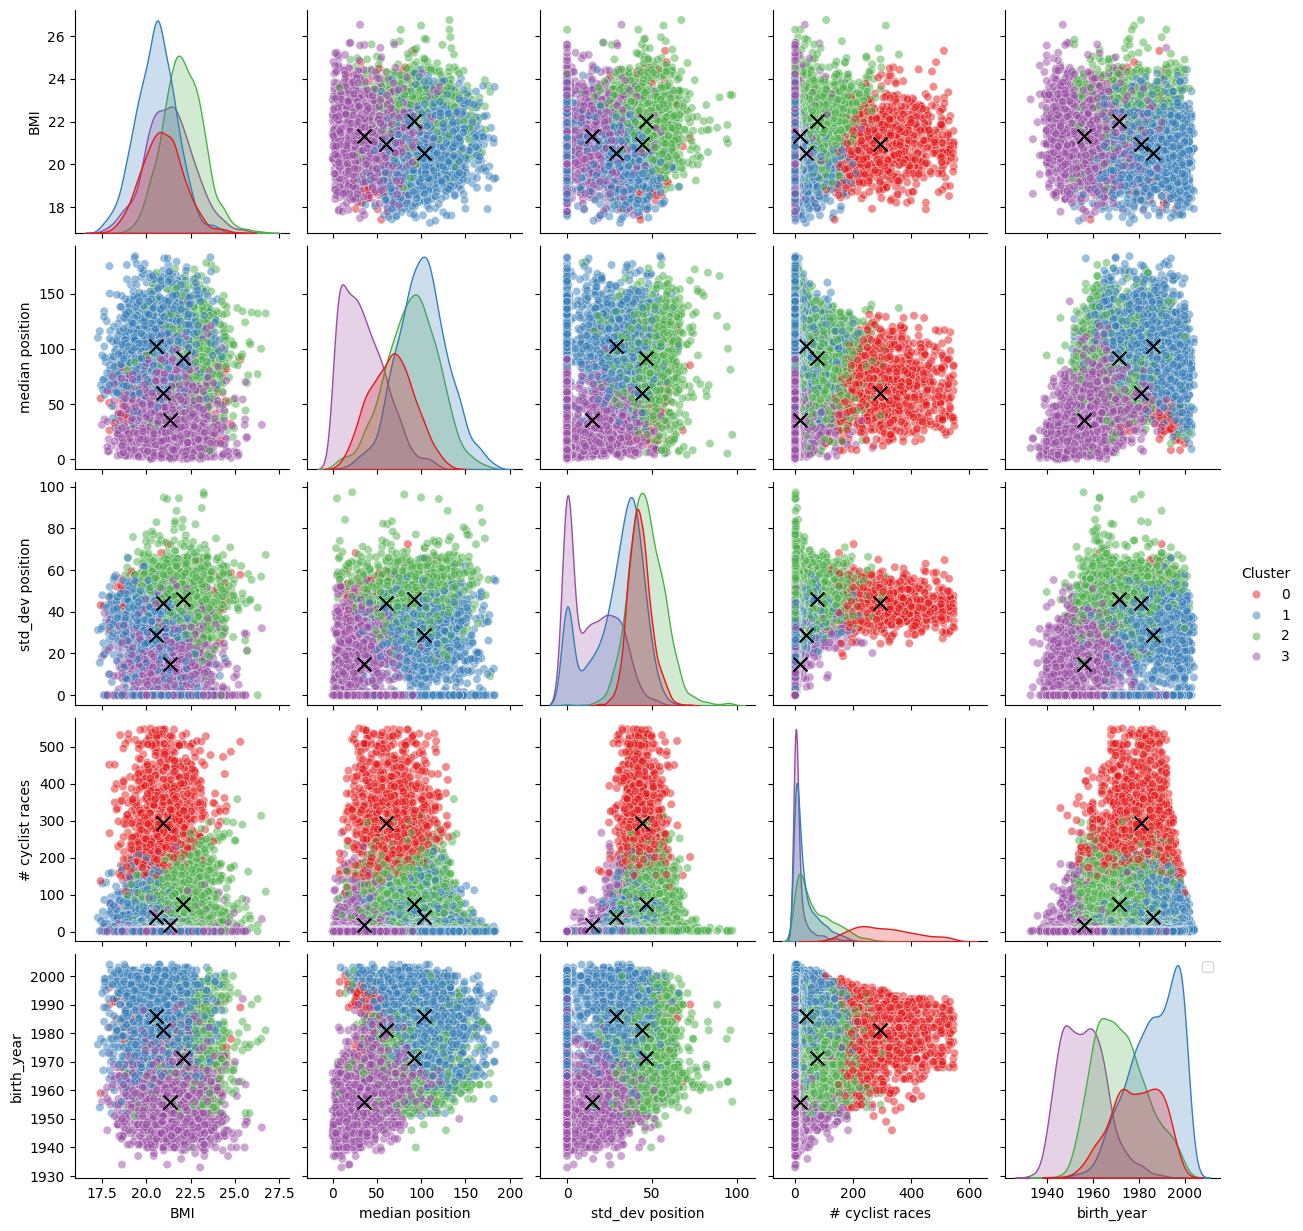

In [3018]:
clusters_pairplot(numeric_cyclists_df, centroids)

### Pairplot analysis

By analyzing the paiplot above, we can try to analyze the 4 clusters and try to catch any relationships and patterns between the characteristics of the clusters that we were unable to catch with the box plots
- **Cluster 0**: 

  - **_std\_dev position_** vs **_# cyclist races**: cyclists with a high number of races tend to have higher standard deviations in their race positions, reflecting more variability in their performance. But this is also quite normal.
  
  - **_# cyclist races_** vs **_birth\_year_**: it seems that cyclists born in more recent years, tend to participate to more races.

- **Cluster 1**: 

  - **_birth\_year_** vs **_median position_**: it seems like that there is a light relationship. Cyclists with worse rankings (higher median positions) tend to be born in earlier years and viceversa.

  - **_median position_** vs **_BMI_**: there is a weak relationship: cyclists with better performance (low median position) have lower BMI values.

  - **_std\_dev position_** vs **_median position_**: cyclists with higher standard deviations in race positions tend to have better median position.
  
- **Cluster 2**: 

  -  **_BMI_** vs **_# cyclist races_**: it appears that cyclists with higher BMI have participated to more races.

  -  **_BMI_** vs **_std\_dev position_**: cyclists with higher BMI seems to have more consistent performances (lower std_dev position).
  
  -  **# cyclist races** vs **_std\_dev position_**: there is a slight relation: higher values of standard deviation of position correspond to lower number of cyclist races.
  
- **Cluster 3**: 
  
  - **_# cyclist races_** vs **_birth\_year_**: in this cluster, cyclists born in more recent years, tend do partecipate to more races, as in Cluster 0.
  
  - **_birth\_year_** vs **_median position_**: it seems that cyclist born after 1960s, have got worse median position (higher values)
  
  - **_std\_dev position_** vs **_# cyclist races**: as in Cluster 0, cyclists with a high number of races appear to have higher standard deviations in their race positions, reflecting more variability in their performance.
 



 

## Geographic distribution of cyclists across clusters
Here we analyzed the geographic distribution of cyclists across clusters by grouping them based on their geographic area and visualized the results. A bar chart was used to compare the counts of cyclists from different regions within each cluster. The chart highlights the relationships between geographic regions and cluster assignments, providing insights into how cyclists from various areas are distributed across the clusters.

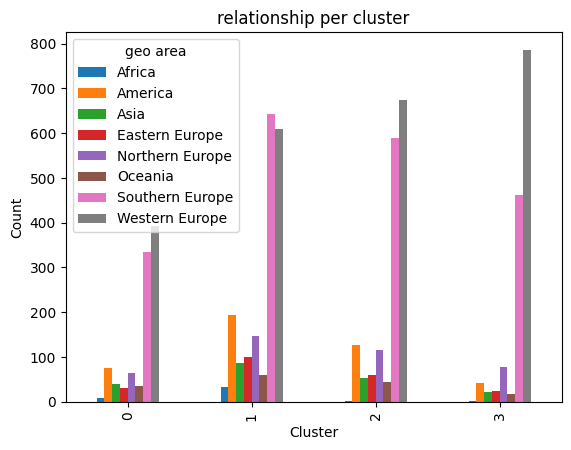

In [3019]:
cross_df = pandas.crosstab(best_kmeans.labels_, cyclists['geo area'])

cross_df.plot(kind='bar', stacked=False, 
                   title='relationship per cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()

# Clustering for races

## Outliers Detection

In [3020]:
numerical_cols = races.select_dtypes(include=['float64', 'int64', 'Int64']).columns
numerical_cols

Index(['points', 'uci_points', 'length', 'climb_total', 'profile',
       'startlist_quality', 'average_temperature', 'is_tarmac', 'is_cobbled',
       'is_gravel', 'climb/length', 'median_delta', 'std_delta'],
      dtype='object')

In [3021]:
numeric_races_df = races[numerical_cols]
numeric_races_df

,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,climb/length,median_delta,std_delta
0,100,NaN,162000,1101,1.0,1241,NaN,1,0,0,0.006796,27.0,6.847590
1,80,100.0,196000,5575,5.0,821,NaN,1,0,0,0.028444,1957.0,873.835670
2,100,120.0,128000,781,1.0,1699,NaN,1,0,0,0.006102,29.0,44.079531
3,50,NaN,8100,68,NaN,804,NaN,1,0,0,0.008395,53.0,27.154498
4,100,120.0,192900,3743,3.0,1551,24.0,1,0,0,0.019404,1376.0,675.354230
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5276,80,100.0,148000,1441,1.0,881,NaN,1,0,0,0.009736,77.0,120.702086
5277,275,NaN,273000,2648,1.0,808,NaN,0,0,0,0.009700,270.0,327.665558
5278,50,NaN,185000,1726,NaN,779,NaN,1,0,0,0.009330,0.0,0.000000
5279,50,50.0,136400,1880,2.0,1045,NaN,1,0,0,0.013783,209.0,176.293335


In [3022]:
numeric_races_df.isna().sum()

points                    0
uci_points             3682
length                    0
climb_total               0
profile                2408
startlist_quality         0
average_temperature    5076
is_tarmac                 0
is_cobbled                0
is_gravel                 0
climb/length              0
median_delta              0
std_delta                 0
dtype: int64

In [3023]:
numeric_races_df = numeric_races_df.dropna(axis=1, how='any')
numeric_races_df.isna().sum()

points               0
length               0
climb_total          0
startlist_quality    0
is_tarmac            0
is_cobbled           0
is_gravel            0
climb/length         0
median_delta         0
std_delta            0
dtype: int64

In [3024]:
numeric_races_df = numeric_races_df[['points', 'climb/length', 'median_delta', 'std_delta', 'startlist_quality', 'climb_total', 'length']]
numeric_races_df

,points,climb/length,median_delta,std_delta,startlist_quality,climb_total,length
0,100,0.006796,27.0,6.847590,1241,1101,162000
1,80,0.028444,1957.0,873.835670,821,5575,196000
2,100,0.006102,29.0,44.079531,1699,781,128000
3,50,0.008395,53.0,27.154498,804,68,8100
4,100,0.019404,1376.0,675.354230,1551,3743,192900
...,...,...,...,...,...,...,...
5276,80,0.009736,77.0,120.702086,881,1441,148000
5277,275,0.009700,270.0,327.665558,808,2648,273000
5278,50,0.009330,0.0,0.000000,779,1726,185000
5279,50,0.013783,209.0,176.293335,1045,1880,136400


Check pearson correlation between these non-nan numeric features

,points,climb/length,median_delta,std_delta,startlist_quality,climb_total,length
points,1.000000,-0.064540,0.035331,0.051223,0.150270,0.222756,0.443516
climb/length,-0.064540,1.000000,0.191377,0.223502,0.015309,0.430213,-0.171295
median_delta,0.035331,0.191377,1.000000,0.793629,0.096597,0.303302,0.075307
std_delta,0.051223,0.223502,0.793629,1.000000,0.069962,0.301224,0.117848
startlist_quality,0.150270,0.015309,0.096597,0.069962,1.000000,0.095901,0.075864
climb_total,0.222756,0.430213,0.303302,0.301224,0.095901,1.000000,0.590508
length,0.443516,-0.171295,0.075307,0.117848,0.075864,0.590508,1.000000


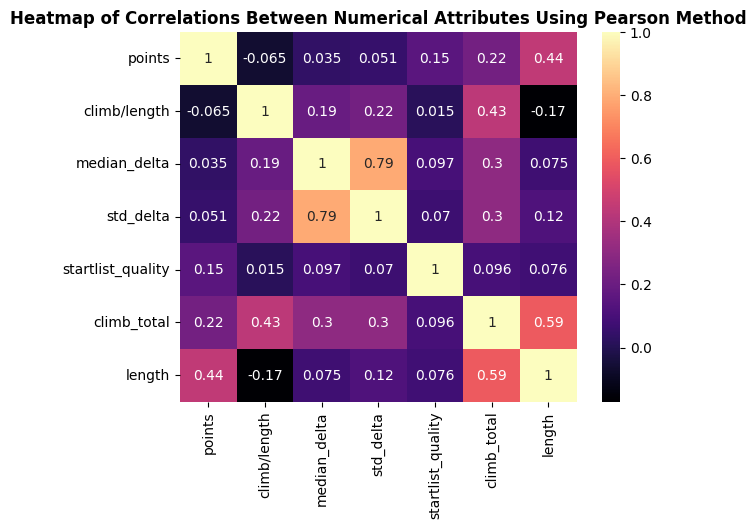

In [3025]:
pearson_matrix = numeric_races_df.corr(method='pearson')
display(pearson_matrix)
sbn.heatmap(pearson_matrix, annot=True, cmap="magma")
plt.title("Heatmap of Correlations Between Numerical Attributes Using Pearson Method", fontweight='bold')
plt.show()
plt.close()

Since _std\_delta_ and _median\_delta_ are highly correlated, we decide to drop _std\_delta_. Also _climb\_total_ and _length_ are moderately correlated.
Given that we already have the feature _climb/total_, we chose to drop _climb\_total_  while retaining _length_

In [3026]:
numeric_races_df = numeric_races_df.drop(['std_delta', 'climb_total'], axis=1)
numeric_races_df

,points,climb/length,median_delta,startlist_quality,length
0,100,0.006796,27.0,1241,162000
1,80,0.028444,1957.0,821,196000
2,100,0.006102,29.0,1699,128000
3,50,0.008395,53.0,804,8100
4,100,0.019404,1376.0,1551,192900
...,...,...,...,...,...
5276,80,0.009736,77.0,881,148000
5277,275,0.009700,270.0,808,273000
5278,50,0.009330,0.0,779,185000
5279,50,0.013783,209.0,1045,136400


In [3027]:
numeric_columns = numeric_races_df.columns
numeric_races_df['_url'] = races['_url']
numeric_races_df

,points,climb/length,median_delta,startlist_quality,length,_url
0,100,0.006796,27.0,1241,162000,tour-de-france/1978/stage-6
1,80,0.028444,1957.0,821,196000,vuelta-a-espana/2016/stage-14
2,100,0.006102,29.0,1699,128000,tour-de-france/2019/stage-21
3,50,0.008395,53.0,804,8100,volta-a-catalunya/1999/prologue
4,100,0.019404,1376.0,1551,192900,tour-de-france/2022/stage-9
...,...,...,...,...,...,...
5276,80,0.009736,77.0,881,148000,giro-d-italia/2017/stage-3
5277,275,0.009700,270.0,808,273000,paris-roubaix/2000/result
5278,50,0.009330,0.0,779,185000,paris-nice/1976/stage-2
5279,50,0.013783,209.0,1045,136400,volta-a-catalunya/2016/stage-7


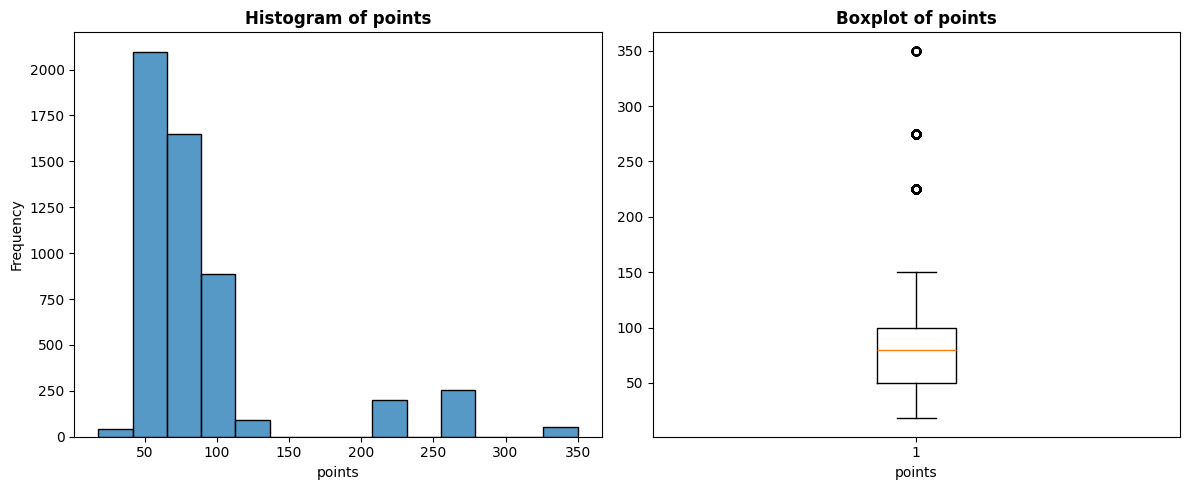

Outliers in points: [np.int64(225), np.int64(275), np.int64(350)]


,Url,Column,Lower Bound,Upper Bound,Outlier Value
13,ronde-van-vlaanderen/1980/result,points,18,175.0,275
15,milano-sanremo/2004/result,points,18,175.0,275
48,la-fleche-wallone/2015/result,points,18,175.0,225
69,liege-bastogne-liege/1999/result,points,18,175.0,275
74,paris-roubaix/2021/result,points,18,175.0,275
...,...,...,...,...,...
5244,milano-sanremo/1996/result,points,18,175.0,275
5248,amstel-gold-race/2013/result,points,18,175.0,225
5268,san-sebastian/2017/result,points,18,175.0,225
5269,gp-quebec/2010/result,points,18,175.0,225


Number of outliers in points: 510


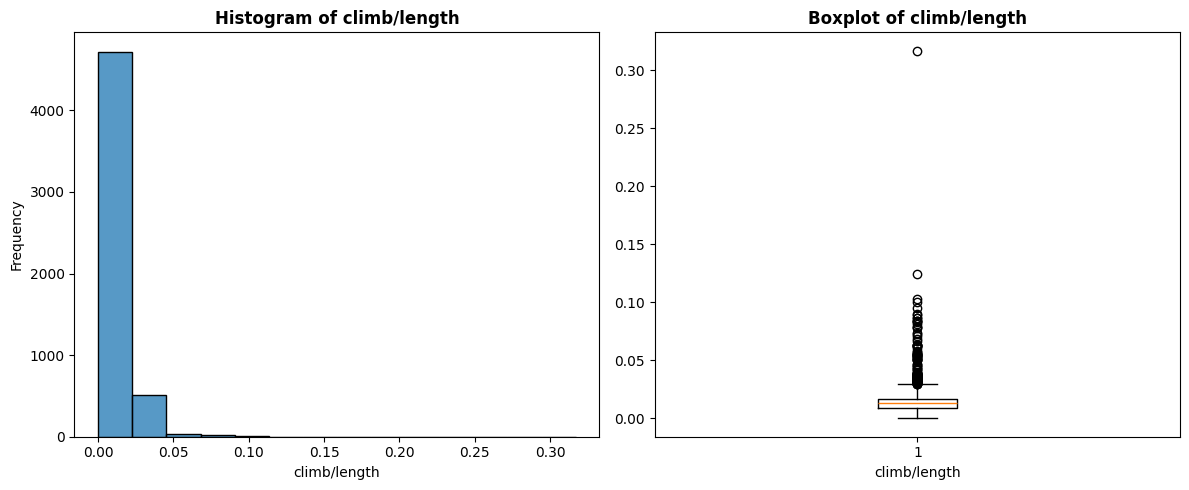

Outliers in climb/length: [np.float64(0.0355151515151515), np.float64(0.0625), np.float64(0.1032608695652173), np.float64(0.0509278350515463), np.float64(0.0380655737704918), np.float64(0.0314965517241379), np.float64(0.08975), np.float64(0.0300884955752212), np.float64(0.0321134751773049), np.float64(0.0417777777777777), np.float64(0.0365653710247349), np.float64(0.0527184466019417), np.float64(0.0712666666666666), np.float64(0.0316091954022988), np.float64(0.05821875), np.float64(0.08375), np.float64(0.0788888888888888), np.float64(0.0510163934426229), np.float64(0.0374453781512605), np.float64(0.0314410774410774), np.float64(0.0343589743589743), np.float64(0.0383529411764705), np.float64(0.0502364864864864), np.float64(0.0423391812865497), np.float64(0.0332473684210526), np.float64(0.0303030303030303), np.float64(0.0305527065527065), np.float64(0.0301204819277108), np.float64(0.095), np.float64(0.0426), np.float64(0.0726851851851851), np.float64(0.0357843137254901), np.float64(0.087

,Url,Column,Lower Bound,Upper Bound,Outlier Value
5,vuelta-a-espana/2017/stage-20,climb/length,0.0,0.03,0.032
18,giro-d-italia/2019/stage-14,climb/length,0.0,0.03,0.032
35,giro-d-italia/2004/stage-18,climb/length,0.0,0.03,0.032
37,vuelta-a-espana/2019/stage-9,climb/length,0.0,0.03,0.035
86,vuelta-a-espana/1993/stage-6,climb/length,0.0,0.03,0.034
...,...,...,...,...,...
5088,tour-de-france/1979/stage-2,climb/length,0.0,0.03,0.061
5161,tour-de-suisse/1976/prologue,climb/length,0.0,0.03,0.090
5169,vuelta-a-espana/1992/stage-9,climb/length,0.0,0.03,0.032
5175,tour-de-france/2021/stage-9,climb/length,0.0,0.03,0.032


Number of outliers in climb/length: 145


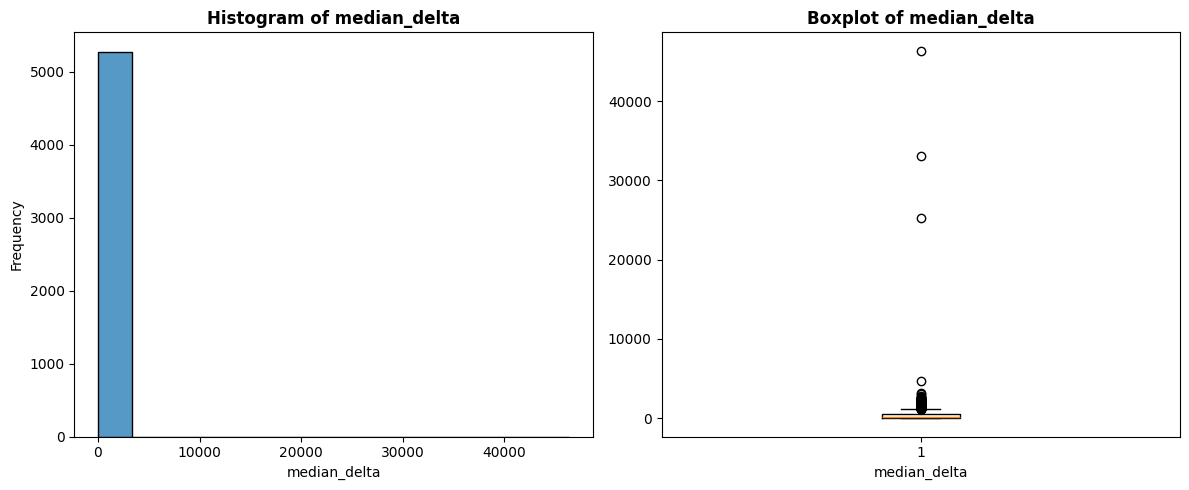

Outliers in median_delta: [np.float64(2048.0), np.float64(2060.0), np.float64(2062.0), np.float64(2072.0), np.float64(2080.0), np.float64(2083.0), np.float64(2090.0), np.float64(2101.0), np.float64(2109.5), np.float64(2120.0), np.float64(2126.0), np.float64(2140.0), np.float64(2154.0), np.float64(2156.0), np.float64(2169.0), np.float64(2185.0), np.float64(2191.0), np.float64(2193.0), np.float64(2199.0), np.float64(2208.0), np.float64(2210.0), np.float64(2216.0), np.float64(2244.0), np.float64(2274.5), np.float64(2365.0), np.float64(2368.5), np.float64(2370.0), np.float64(2373.0), np.float64(2399.0), np.float64(2419.0), np.float64(33140.0), np.float64(2426.0), np.float64(2500.0), np.float64(2562.0), np.float64(2657.0), np.float64(25223.0), np.float64(4751.0), np.float64(2732.0), np.float64(2825.0), np.float64(3018.0), np.float64(3234.0), np.float64(1187.0), np.float64(1189.0), np.float64(1193.0), np.float64(1194.0), np.float64(1195.0), np.float64(1199.0), np.float64(1200.0), np.float64(

,Url,Column,Lower Bound,Upper Bound,Outlier Value
1,vuelta-a-espana/2016/stage-14,median_delta,0.0,1186.25,1957.0
4,tour-de-france/2022/stage-9,median_delta,0.0,1186.25,1376.0
14,volta-a-catalunya/2015/stage-4,median_delta,0.0,1186.25,1669.0
18,giro-d-italia/2019/stage-14,median_delta,0.0,1186.25,1529.0
35,giro-d-italia/2004/stage-18,median_delta,0.0,1186.25,1423.0
...,...,...,...,...,...
5233,giro-d-italia/2015/stage-19,median_delta,0.0,1186.25,2562.0
5255,giro-d-italia/2021/stage-6,median_delta,0.0,1186.25,1287.5
5262,tour-de-romandie/2002/stage-2,median_delta,0.0,1186.25,1860.0
5266,dauphine/2015/stage-6,median_delta,0.0,1186.25,2185.0


Number of outliers in median_delta: 402


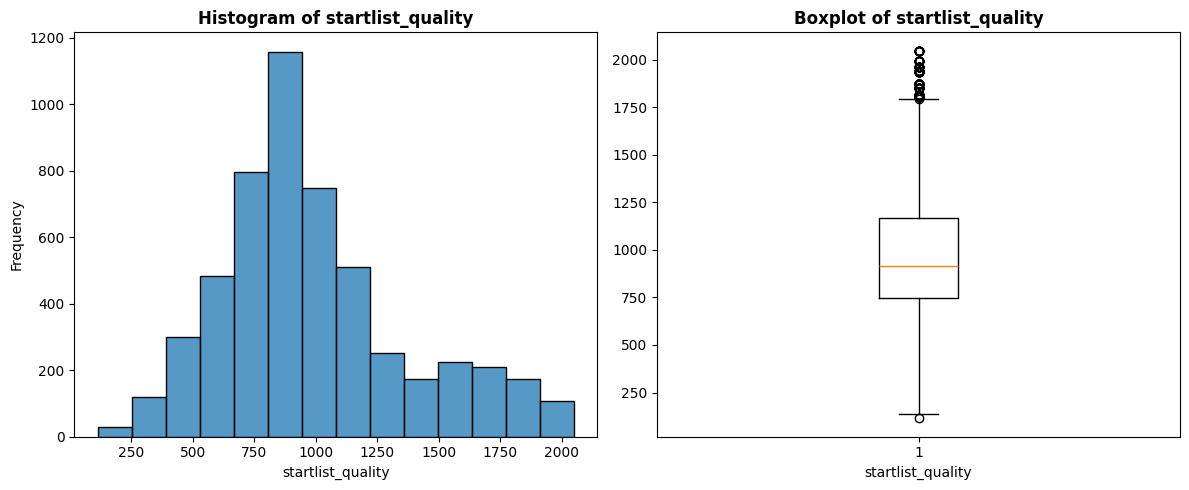

Outliers in startlist_quality: [np.int64(1794), np.int64(1959), np.int64(1994), np.int64(1804), np.int64(1933), np.int64(1871), np.int64(1872), np.int64(115), np.int64(1812), np.int64(1941), np.int64(1849), np.int64(2047)]


,Url,Column,Lower Bound,Upper Bound,Outlier Value
39,tour-de-france/1997/stage-15,startlist_quality,120.0,1792.0,1994
72,tour-de-france/1997/stage-2,startlist_quality,120.0,1792.0,1994
90,tour-de-france/1990/stage-1,startlist_quality,120.0,1792.0,1959
94,tour-de-france/1992/stage-7,startlist_quality,120.0,1792.0,2047
164,tour-de-france/1990/stage-9,startlist_quality,120.0,1792.0,1959
...,...,...,...,...,...
5125,tour-de-france/1987/stage-3,startlist_quality,120.0,1792.0,1812
5153,world-championship/1991/result,startlist_quality,120.0,1792.0,1794
5180,tour-de-france/1991/stage-19,startlist_quality,120.0,1792.0,1933
5190,tour-de-france/1997/stage-7,startlist_quality,120.0,1792.0,1994


Number of outliers in startlist_quality: 260


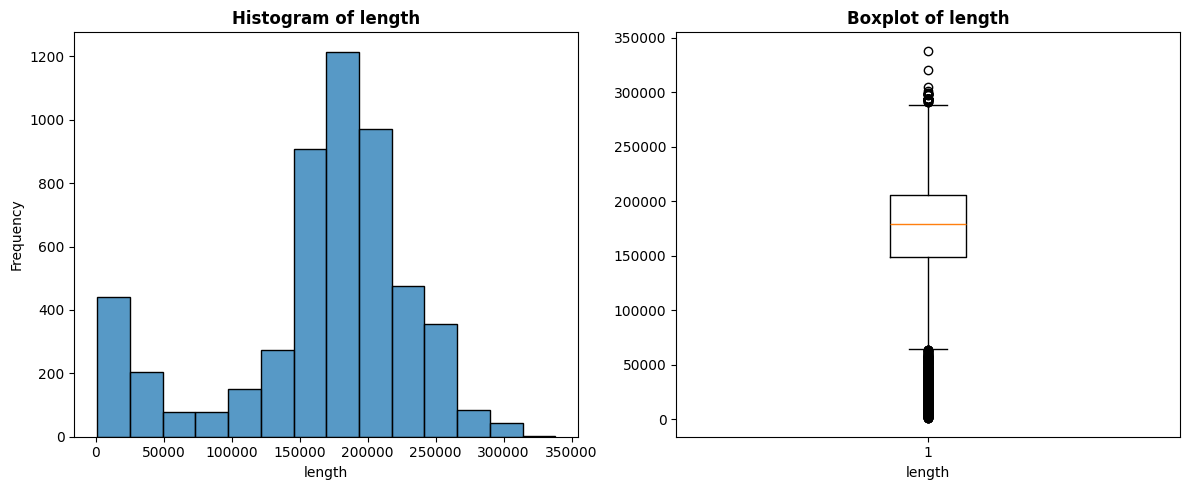

Outliers in length: [np.int64(4100), np.int64(59400), np.int64(8200), np.int64(12300), np.int64(63500), np.int64(16400), np.int64(20500), np.int64(24600), np.int64(36900), np.int64(41000), np.int64(297000), np.int64(53300), np.int64(6200), np.int64(61500), np.int64(14400), np.int64(18500), np.int64(26700), np.int64(30800), np.int64(338000), np.int64(34900), np.int64(39000), np.int64(4200), np.int64(6250), np.int64(59500), np.int64(12400), np.int64(16500), np.int64(20600), np.int64(24700), np.int64(37000), np.int64(293000), np.int64(6300), np.int64(57500), np.int64(10400), np.int64(14500), np.int64(18600), np.int64(26800), np.int64(30900), np.int64(35000), np.int64(291000), np.int64(55500), np.int64(4300), np.int64(8400), np.int64(12500), np.int64(33000), np.int64(37100), np.int64(41200), np.int64(53500), np.int64(6400), np.int64(22800), np.int64(26900), np.int64(31000), np.int64(8500), np.int64(12600), np.int64(18750), np.int64(49500), np.int64(6500), np.int64(18800), np.int64(27000), 

,Url,Column,Lower Bound,Upper Bound,Outlier Value
3,volta-a-catalunya/1999/prologue,length,64250.0,290250.0,8100
6,tour-de-france/1978/stage-14,length,64250.0,290250.0,52000
8,volta-a-catalunya/1981/stage-2b,length,64250.0,290250.0,30000
9,paris-nice/1994/stage-8b,length,64250.0,290250.0,12500
15,milano-sanremo/2004/result,length,64250.0,290250.0,294000
...,...,...,...,...,...
5241,milano-sanremo/2019/result,length,64250.0,290250.0,291000
5243,tour-de-france/1990/stage-5,length,64250.0,290250.0,301000
5244,milano-sanremo/1996/result,length,64250.0,290250.0,294000
5260,vuelta-a-espana/1997/stage-21,length,64250.0,290250.0,43000


Number of outliers in length: 749


In [3028]:
for column in numeric_columns:
    show_hist_and_box_plot(numeric_races_df,column)
    bounds = calculate_outlier_bounds(numeric_races_df, column)
    lower_bound = round(bounds['lower'], 3)
    upper_bound = round(bounds['upper'], 3)
    
    outliers_list = []
    outliers = numeric_races_df[
        (numeric_races_df[column] < lower_bound) | (numeric_races_df[column] > upper_bound)
    ]

    column_outliers_count = len(outliers)

    column_outliers_df = pd.DataFrame({
        "Url": outliers['_url'],
        "Column": column,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Value": outliers[column].round(3)
    })
    if(column_outliers_count > 0):
        display(column_outliers_df)
    print(f"Number of outliers in {column}: {column_outliers_count}")

In [3029]:
rows_with_outliers = check_all_outliers(numeric_races_df)

,points,climb/length,median_delta,startlist_quality,length,outlier_count,outlier_percentage
1,False,False,True,False,False,1,20.0
3,False,False,False,False,True,1,20.0
4,False,False,True,False,False,1,20.0
5,False,True,False,False,False,1,20.0
6,False,False,False,False,True,1,20.0
...,...,...,...,...,...,...,...
5268,True,False,False,False,False,1,20.0
5269,True,False,False,False,False,1,20.0
5275,False,False,True,False,False,1,20.0
5277,True,False,False,False,False,1,20.0


Total number of rows: 5281
Total rows with outliers: 1823
Percentage of rows with outliers: 34.52%


In [3030]:
rows_with_outliers['outlier_count'].value_counts()

outlier_count
1    1593
2     215
3      15
Name: count, dtype: int64

In [3031]:
rows_with_outliers[rows_with_outliers['outlier_count'] == 2]

,points,climb/length,median_delta,startlist_quality,length,outlier_count,outlier_percentage
15,True,False,False,False,True,2,40.0
18,False,True,True,False,False,2,40.0
35,False,True,True,False,False,2,40.0
37,False,True,True,False,False,2,40.0
39,False,False,True,True,False,2,40.0
...,...,...,...,...,...,...,...
5175,False,True,True,False,False,2,40.0
5197,False,True,False,False,True,2,40.0
5241,True,False,False,False,True,2,40.0
5243,False,False,False,True,True,2,40.0


In [3032]:
rows_with_outliers[rows_with_outliers['outlier_count'] == 3]

,points,climb/length,median_delta,startlist_quality,length,outlier_count,outlier_percentage
188,False,True,True,True,False,3,60.0
536,False,True,True,True,False,3,60.0
832,False,True,False,True,True,3,60.0
918,False,True,True,True,False,3,60.0
1144,False,True,False,True,True,3,60.0
1156,False,True,False,True,True,3,60.0
1534,False,True,True,True,False,3,60.0
2784,False,True,False,True,True,3,60.0
3762,False,True,True,True,False,3,60.0
3766,False,True,True,True,False,3,60.0


### Outliers elimination

#### points (510)

In [3033]:
numeric_races_df['points'].value_counts().sort_index()

points
18        2
20        7
30       30
35        1
50     2098
70       21
75       32
80     1597
100     889
125      93
150       1
225     201
275     256
350      53
Name: count, dtype: int64

In [3034]:
bound = calculate_outlier_bounds(numeric_races_df, "points")
lower_bound_points = bound['lower']
upper_bound_points = bound['upper']

In [3035]:
print(lower_bound_points)
print(upper_bound_points)

18
175.0


In [3036]:
analyze_outliers(numeric_races_df, "points", lower_bound_points, upper_bound_points, 7, 7, 20, 20)

Outliers above upper bound (175.0): 510
Outliers below lower bound (18): 0
Total outliers: 510
Number of outliers in the range of [175.0, 195.0]: 0
Number of outliers in the range of [195.0, 215.0]: 0
Number of outliers in the range of [215.0, 235.0]: 201
Number of outliers in the range of [235.0, 255.0]: 0
Number of outliers in the range of [255.0, 275.0]: 0
Number of outliers in the range of [275.0, 295.0]: 256
Number of outliers in the range of [295.0, 315.0]: 0
Number of outliers > 315.0: 53

No outliers below the lower bound.


The most extreme outliers appear to be those with values > 315, which are all points = 350.

In [3037]:
numeric_races_df[numeric_races_df['points'] > 315]['points'].value_counts()

points
350    53
Name: count, dtype: int64

Points column represents fixed scores assigned to various types of cycling races. These scores are predetermined, and the values range from 18 to 350. According to the outliers detection, values above **175** are considered outliers. However, this results in identifying **510** rows as outliers, which is a substantial portion of the dataset. Removing all these rows would drastically alter the distribution. To address this issue, we analyzed different portions above 175 to identify the most extreme outliers.

Through this process, we observed that the most extreme outliers were those with the value 350, and all 53 of them are identical. These rows represent fixed scores that are meaningful in the context of the dataset. 
Since these high scores are predetermined and correspond to a specific category of races, it makes more sense to retain them in the dataset. This ensures that the clusters or future analyses are not biased by the absence of certain race types.

#### climb/length (145)

In [3038]:
bound = calculate_outlier_bounds(numeric_races_df, "climb/length")
lower_bound_climb_length = bound['lower']
upper_bound_climb_length = bound['upper']

In [3039]:
print(lower_bound_climb_length)
print(upper_bound_climb_length)

6.864988558352403e-05
0.029871531553300402


In [3040]:
analyze_outliers(numeric_races_df, "climb/length", lower_bound_climb_length, upper_bound_climb_length, 8, 8, 0.01, 0.01)

Outliers above upper bound (0.029871531553300402): 147
Outliers below lower bound (6.864988558352403e-05): 0
Total outliers: 147
Number of outliers in the range of [0.029871531553300402, 0.0398715315533004]: 65
Number of outliers in the range of [0.0398715315533004, 0.0498715315533004]: 31
Number of outliers in the range of [0.0498715315533004, 0.0598715315533004]: 15
Number of outliers in the range of [0.0598715315533004, 0.0698715315533004]: 14
Number of outliers in the range of [0.0698715315533004, 0.0798715315533004]: 5
Number of outliers in the range of [0.0798715315533004, 0.0898715315533004]: 8
Number of outliers in the range of [0.0898715315533004, 0.0998715315533004]: 4
Number of outliers in the range of [0.0998715315533004, 0.1098715315533004]: 3
Number of outliers > 0.1098715315533004: 2

No outliers below the lower bound.


Given the ranges above, it might be quite "safe" to try to consider outliers beyond 0.069 as extreme. It is about the 99.6th percentile.

In [3041]:
upper_extreme_quantile = numeric_races_df["climb/length"].quantile(0.996)
upper_extreme_quantile

np.float64(0.06634685185185217)

In [3042]:
cleaned_races_df = numeric_races_df.copy()  

cleaned_races_df = cleaned_races_df[
    (cleaned_races_df['climb/length'] <=  upper_extreme_quantile)
]

print(f"Remaining rows after removal: {len(cleaned_races_df)}")
print(f"Removed rows: {len(numeric_races_df) - len(cleaned_races_df)}")

Remaining rows after removal: 5259
Removed rows: 22


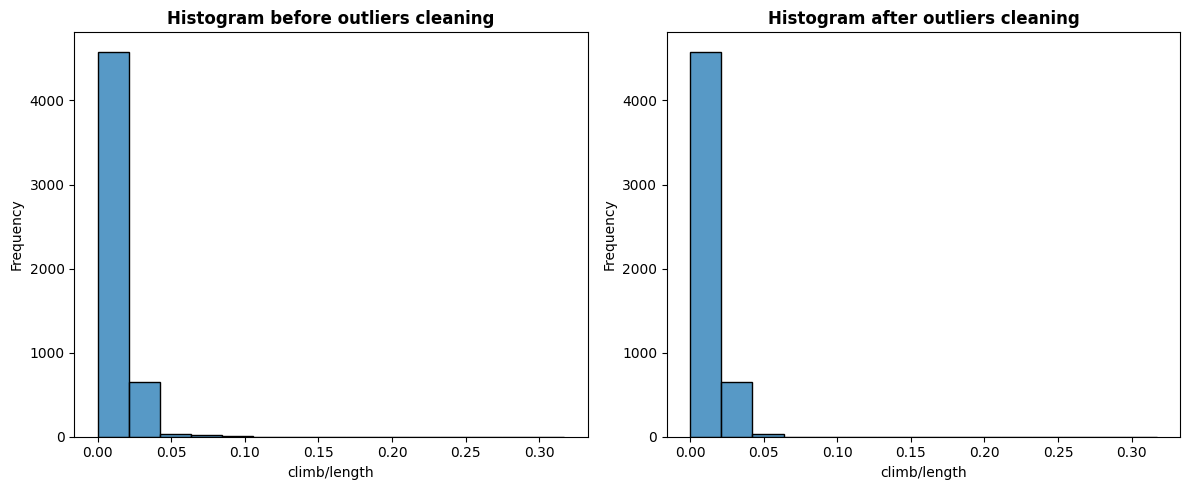

In [3043]:
compare_distributions_consistent(numeric_races_df, cleaned_races_df, "climb/length")

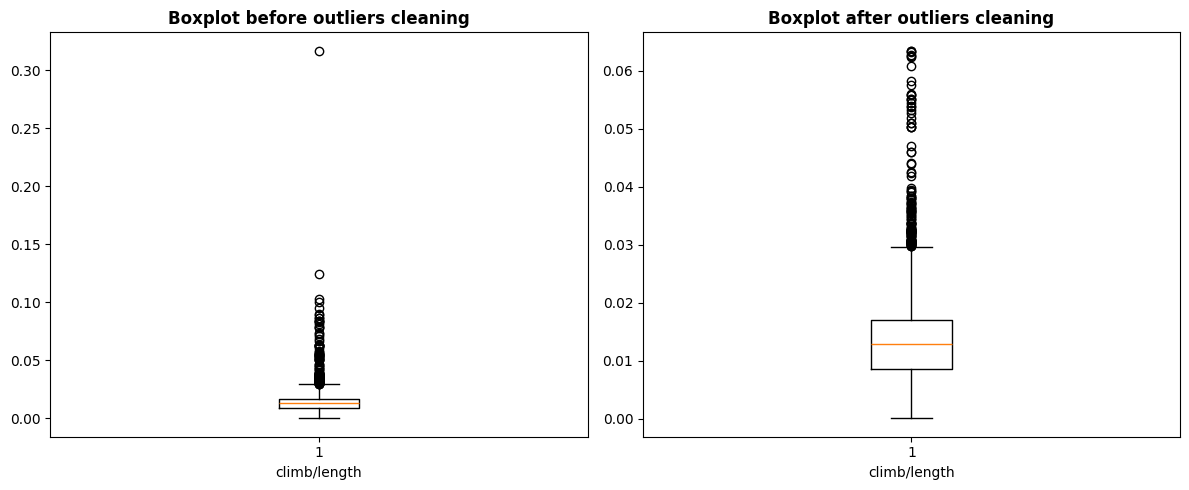

In [3044]:
compare_box_plots(numeric_races_df, cleaned_races_df, "climb/length")

As we can see, the distribution has not been significantly altered. The box plot now provides a better and more understandable visualization.

#### median_delta (402)

In [3045]:
bound = calculate_outlier_bounds(numeric_races_df, "median_delta")
lower_bound_median_delta= bound['lower']
upper_bound_median_delta = bound['upper']

In [3046]:
print(lower_bound_median_delta)
print(upper_bound_median_delta)

0.0
1186.25


In [3047]:
analyze_outliers(numeric_races_df, "median_delta", lower_bound_median_delta, upper_bound_median_delta, 6, 6, 1000, 1000)

Outliers above upper bound (1186.25): 402
Outliers below lower bound (0.0): 0
Total outliers: 402
Number of outliers in the range of [1186.25, 2186.25]: 375
Number of outliers in the range of [2186.25, 3186.25]: 22
Number of outliers in the range of [3186.25, 4186.25]: 1
Number of outliers in the range of [4186.25, 5186.25]: 1
Number of outliers in the range of [5186.25, 6186.25]: 0
Number of outliers in the range of [6186.25, 7186.25]: 0
Number of outliers > 7186.25: 3

No outliers below the lower bound.


In [3048]:
numeric_races_df['median_delta'].value_counts().sort_index()

median_delta
0.0        1195
0.5           1
1.0          19
2.0          39
2.5           1
           ... 
3234.0        1
4751.0        1
25223.0       1
33140.0       1
46380.0       1
Name: count, Length: 1483, dtype: int64

The 3 most extreme values, above _7186.25_ are extremely higher compared to the others. 

In [3049]:
numeric_races_df[numeric_races_df['median_delta'] > 7186.25]['median_delta'].value_counts()

median_delta
33140.0    1
46380.0    1
25223.0    1
Name: count, dtype: int64

As we can see, the three values beyond 7186.25 can undoubtedly be considered the most extreme outliers. However, we could also include other extreme outliers, given that most values are concentrated within the first two intervals, up to 3186.25. Therefore, we can consider all values exceeding this threshold (3186.25) as extreme outliers.

This corresponds approximately to the 0.9992 quantile, meaning that only 0.08% of the data lies above this threshold. 

In [3050]:
upper_extreme_quantile = numeric_races_df["median_delta"].quantile(0.9992)
upper_extreme_quantile

np.float64(3185.6159999999654)

In [3051]:
len_before_cleaning = len(cleaned_races_df)
cleaned_races_df = cleaned_races_df[(cleaned_races_df['median_delta'] <= upper_extreme_quantile)]

print(f"Remaining rows after removal: {len(cleaned_races_df)}")
print(f"Removed rows: {len_before_cleaning - len(cleaned_races_df)}")

Remaining rows after removal: 5254
Removed rows: 5


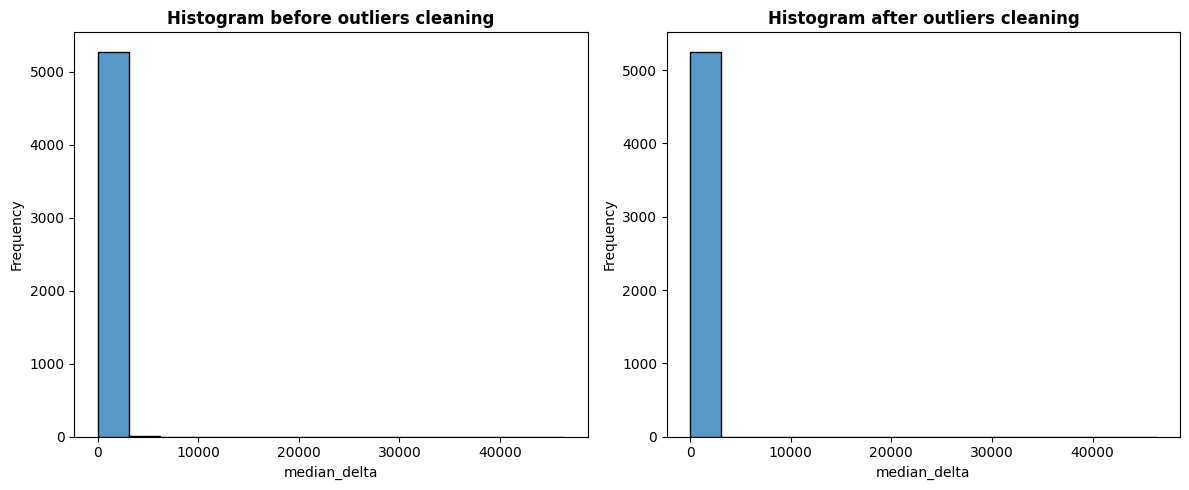

In [3052]:
compare_distributions_consistent(numeric_races_df, cleaned_races_df, "median_delta")

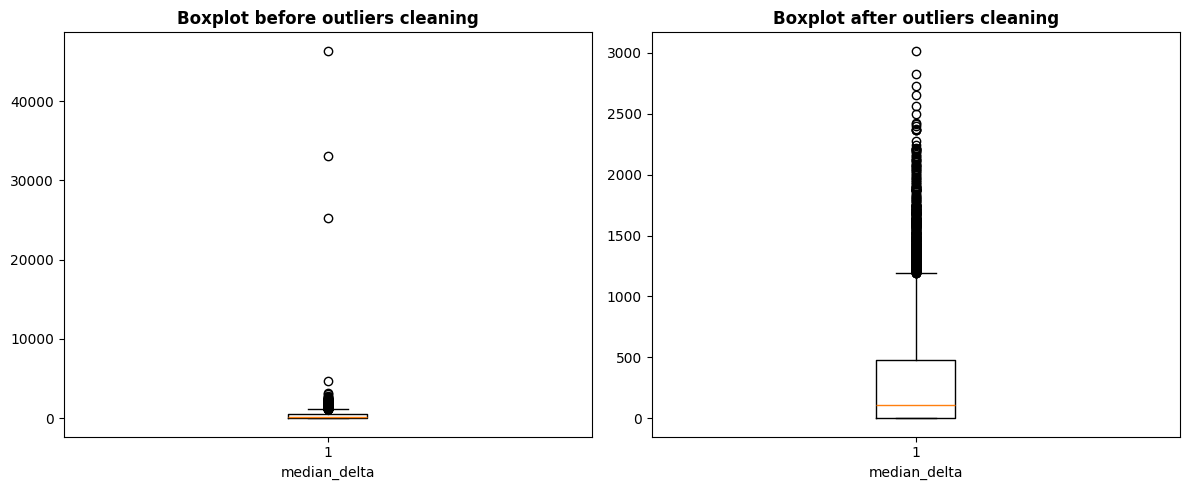

In [3053]:
compare_box_plots(numeric_races_df, cleaned_races_df, "median_delta")

After removing the most extreme outliers, we can observe a significant change in the boxplot. Previously, the extreme values heavily skewed the visualization, making it difficult to interpret the majority of the data. Now, with the extreme outliers removed, the boxplot provides a clearer view of the distribution. Importantly, while the visualization has been adjusted, the distribution itself has not been significantly altered.

#### startlist_quality (260)

In [3054]:
bound = calculate_outlier_bounds(numeric_races_df, "startlist_quality")
lower_bound_startlist= bound['lower']
upper_bound_startlist = bound['upper']

In [3055]:
print(lower_bound_startlist)
print(upper_bound_startlist)

120.0
1792.0


In [3073]:
analyze_outliers(numeric_races_df, "startlist_quality", lower_bound_startlist, upper_bound_startlist, 15, 1, 20, 50)

Outliers above upper bound (1792.0): 259
Outliers below lower bound (120.0): 1
Total outliers: 260
Number of outliers in the range of [1792.0, 1812.0]: 21
Number of outliers in the range of [1812.0, 1832.0]: 45
Number of outliers in the range of [1832.0, 1852.0]: 21
Number of outliers in the range of [1852.0, 1872.0]: 19
Number of outliers in the range of [1872.0, 1892.0]: 45
Number of outliers in the range of [1892.0, 1912.0]: 0
Number of outliers in the range of [1912.0, 1932.0]: 0
Number of outliers in the range of [1932.0, 1952.0]: 44
Number of outliers in the range of [1952.0, 1972.0]: 21
Number of outliers in the range of [1972.0, 1992.0]: 0
Number of outliers in the range of [1992.0, 2012.0]: 22
Number of outliers in the range of [2012.0, 2032.0]: 0
Number of outliers in the range of [2032.0, 2052.0]: 21
Number of outliers in the range of [2052.0, 2072.0]: 0
Number of outliers in the range of [2072.0, 2092.0]: 0
Number of outliers > 2092.0: 0

Number of outliers in the range of 

Given that the outliers are fairly evenly distributed, there aren’t any outliers that stand out as more extreme than the others. Therefore, it could be reasonable to keep them all without removing any.

#### length (749)

In [ ]:
bound = calculate_outlier_bounds(numeric_races_df, "length")
lower_bound_length= bound['lower']
upper_bound_length = bound['upper']

In [3075]:
print(lower_bound_length)
print(upper_bound_length)

64250.0
290250.0


Since we need to account for multiple intervals, we execute analyze_outliers twice: once for the most extreme low-end outliers and once for the most extreme high-end outliers.

In [3104]:
# high-end outliers
analyze_outliers(numeric_races_df, "length", lower_bound_length, upper_bound_length, 20, 0, 1000, 0)

Outliers above upper bound (290250.0): 45
Outliers below lower bound (64250.0): 704
Total outliers: 749
Number of outliers in the range of [290250.0, 291250.0]: 3
Number of outliers in the range of [291250.0, 292250.0]: 1
Number of outliers in the range of [292250.0, 293250.0]: 4
Number of outliers in the range of [293250.0, 294250.0]: 24
Number of outliers in the range of [294250.0, 295250.0]: 0
Number of outliers in the range of [295250.0, 296250.0]: 0
Number of outliers in the range of [296250.0, 297250.0]: 2
Number of outliers in the range of [297250.0, 298250.0]: 5
Number of outliers in the range of [298250.0, 299250.0]: 2
Number of outliers in the range of [299250.0, 300250.0]: 0
Number of outliers in the range of [300250.0, 301250.0]: 1
Number of outliers in the range of [301250.0, 302250.0]: 0
Number of outliers in the range of [302250.0, 303250.0]: 0
Number of outliers in the range of [303250.0, 304250.0]: 0
Number of outliers in the range of [304250.0, 305250.0]: 1
Number of 

It is not easy to establish which ones are considered more extreme, but let's try to consider those few that go beyond _299250_

In [3112]:
# low-end outliers
analyze_outliers(numeric_races_df, "length", lower_bound_length, upper_bound_length, 0, 26, 0, 4000)

Outliers above upper bound (290250.0): 45
Outliers below lower bound (64250.0): 704
Total outliers: 749
Number of outliers > 290250.0: 45

Number of outliers in the range of [60250.0, 64250.0]: 12
Number of outliers in the range of [56250.0, 60250.0]: 15
Number of outliers in the range of [52250.0, 56250.0]: 19
Number of outliers in the range of [48250.0, 52250.0]: 16
Number of outliers in the range of [44250.0, 48250.0]: 25
Number of outliers in the range of [40250.0, 44250.0]: 29
Number of outliers in the range of [36250.0, 40250.0]: 39
Number of outliers in the range of [32250.0, 36250.0]: 36
Number of outliers in the range of [28250.0, 32250.0]: 40
Number of outliers in the range of [24250.0, 28250.0]: 38
Number of outliers in the range of [20250.0, 24250.0]: 42
Number of outliers in the range of [16250.0, 20250.0]: 62
Number of outliers in the range of [12250.0, 16250.0]: 50
Number of outliers in the range of [8250.0, 12250.0]: 86
Number of outliers in the range of [4250.0, 8250.0

Given that the low-end outliers below the lower bound are fairly evenly distributed, none of them stand out as significantly more extreme than the others. Therefore, it could be reasonable to retain them all.

So, we will focus on removing only the few considered extreme above the upper bound. Before we supposed to consider those above 299250 as extreme outliers, it corresponds approximately the 0.9992 quantile.

In [3115]:
upper_extreme_quantile = numeric_races_df["length"].quantile(0.9992)
upper_extreme_quantile

np.float64(299000.0)

In [3116]:
len_before_cleaning = len(cleaned_races_df)
cleaned_races_df = cleaned_races_df[(cleaned_races_df['length'] <= upper_extreme_quantile)]

print(f"Remaining rows after removal: {len(cleaned_races_df)}")
print(f"Removed rows: {len_before_cleaning - len(cleaned_races_df)}")

Remaining rows after removal: 5250
Removed rows: 4


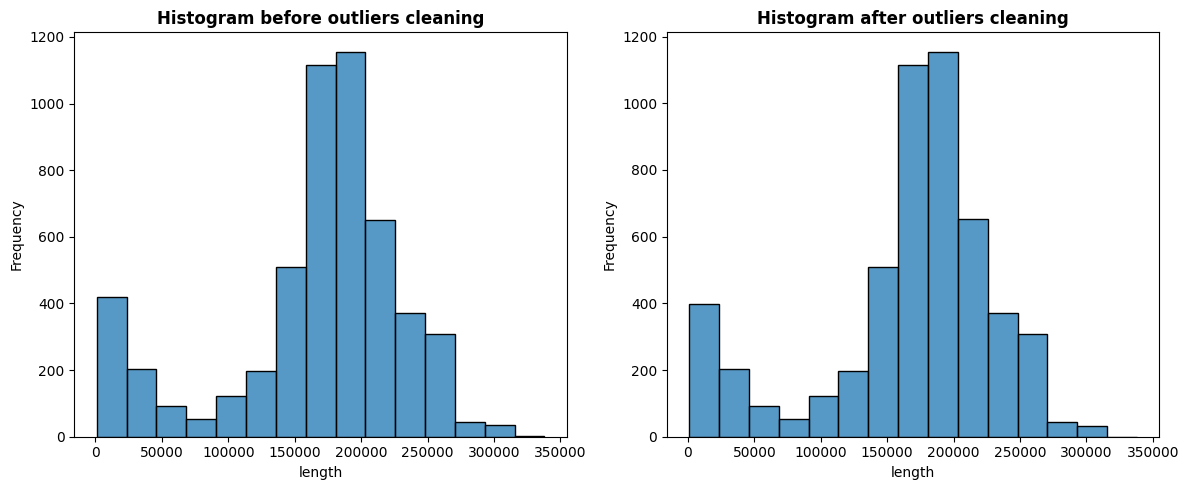

In [3117]:
compare_distributions_consistent(numeric_races_df, cleaned_races_df, "length")

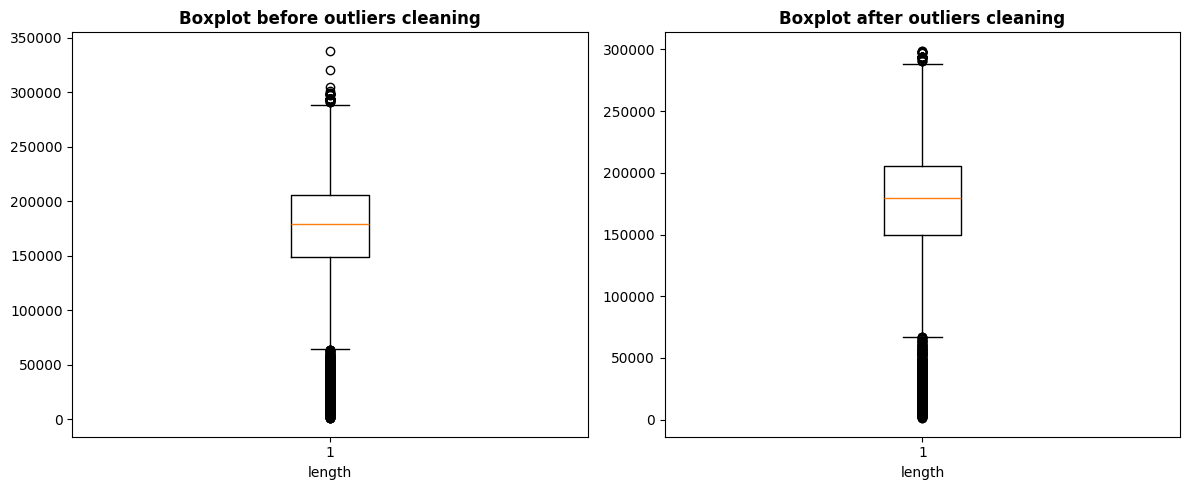

In [3118]:
compare_box_plots(numeric_races_df, cleaned_races_df, "length")

As expected, removing only 4 outliers does not impact the distribution or the box plot in any meaningful way.

## Data Normalization

In [3057]:
numeric_races_df = numeric_races_df.drop('_url', axis=1)
standardizer = standardize_fun(numeric_races_df)
standardized_races_df = standardizer['standardized_df']

        points  climb/length  median_delta  startlist_quality    length
0     0.171536     -0.759354     -0.332395           0.663219 -0.054293
1    -0.154268      1.508052      1.655025          -0.440839  0.446565
2     0.171536     -0.832122     -0.330335           1.867167 -0.555152
3    -0.642976     -0.591897     -0.305621          -0.485527 -2.321415
4     0.171536      0.561182      1.056740           1.478119  0.400899
...        ...           ...           ...                ...       ...
5276 -0.154268     -0.451394     -0.280907          -0.283116 -0.260529
5277  3.022329     -0.455254     -0.082165          -0.475012  1.580862
5278 -0.642976     -0.493998     -0.360198          -0.551244  0.284523
5279 -0.642976     -0.027555     -0.144980           0.147992 -0.431411
5280 -0.154268     -0.723055     -0.315919          -0.291002 -2.316996

[5281 rows x 5 columns]


## PCA
We apply Principal Component Analysis (PCA) to the standardized dataset (standardized_races_df) to reduce its dimensionality while preserving 90% of the variance. It calculates the number of principal components required to achieve this variance threshold and transforms the dataset into the PCA-reduced spac

In [3058]:
pca_instance = PCA(n_components=0.90)  # Preserve 90% of the variance
pca_std_numeric_races = pca_instance.fit_transform(standardized_races_df)

print(f"# selected principal components: {pca_instance.n_components_}")

# selected principal components: 5


In [3059]:
# pca = PCA()
# pca.fit(standardized_races_df) 

# # Compute the contribution (loadings) of each feature to each principal component
# loadings = pd.DataFrame(
#     pca.components_.T, # Transpose to align features with components
#     columns=[f'PC{i+1}' for i in range(pca.n_components_)], # Label columns as PC1, PC2, etc.
#     index=numeric_races_df.columns # Use feature names as index
# )

# display(loadings)

# # Calculate the importance of each feature based on the first two principal components
# top_components = loadings.iloc[:, :2].abs().sum(axis=1) 
# top_variables = top_components.sort_values(ascending=False)


# print("\nFeatures sorted by contribution:")
# print(top_variables)


# selected_columns = top_variables.index.tolist()
# print(f"\nSelected columns: {selected_columns}")


## Kmeans grid search

In [3060]:
results = kmeans_grid_search(pca_std_numeric_races)

k: 2 -> silhouette: 0.3461259340005368, sse: 21260.933675586766
k: 3 -> silhouette: 0.34339133812636036, sse: 17483.108765232577, sse reduction: 17.77%
k: 4 -> silhouette: 0.34802340862548364, sse: 14225.318761815548, sse reduction: 18.63%
k: 5 -> silhouette: 0.38820762642685963, sse: 10517.769972730344, sse reduction: 26.06%
k: 6 -> silhouette: 0.38444388591252787, sse: 8960.77702483985, sse reduction: 14.80%
k: 7 -> silhouette: 0.3461641399830468, sse: 7446.918565065, sse reduction: 16.89%
k: 8 -> silhouette: 0.34745537428816237, sse: 6980.147600818902, sse reduction: 6.27%
k: 9 -> silhouette: 0.34870873161349636, sse: 6298.868477142688, sse reduction: 9.76%
k: 10 -> silhouette: 0.3417829264192173, sse: 5692.870873012619, sse reduction: 9.62%
k: 11 -> silhouette: 0.3231549484585064, sse: 5415.56175627743, sse reduction: 4.87%
k: 12 -> silhouette: 0.2861719360395804, sse: 4871.758427613646, sse reduction: 10.04%
k: 13 -> silhouette: 0.26481750894265293, sse: 4608.043166950458, sse red

[{'k': 2, 'sse': 21260.933675586766, 'silhouette': np.float64(0.3461259340005368)}, {'k': 3, 'sse': 17483.108765232577, 'silhouette': np.float64(0.34339133812636036)}, {'k': 4, 'sse': 14225.318761815548, 'silhouette': np.float64(0.34802340862548364)}, {'k': 5, 'sse': 10517.769972730344, 'silhouette': np.float64(0.38820762642685963)}, {'k': 6, 'sse': 8960.77702483985, 'silhouette': np.float64(0.38444388591252787)}, {'k': 7, 'sse': 7446.918565065, 'silhouette': np.float64(0.3461641399830468)}, {'k': 8, 'sse': 6980.147600818902, 'silhouette': np.float64(0.34745537428816237)}, {'k': 9, 'sse': 6298.868477142688, 'silhouette': np.float64(0.34870873161349636)}, {'k': 10, 'sse': 5692.870873012619, 'silhouette': np.float64(0.3417829264192173)}, {'k': 11, 'sse': 5415.56175627743, 'silhouette': np.float64(0.3231549484585064)}, {'k': 12, 'sse': 4871.758427613646, 'silhouette': np.float64(0.2861719360395804)}, {'k': 13, 'sse': 4608.043166950458, 'silhouette': np.float64(0.26481750894265293)}, {'k':

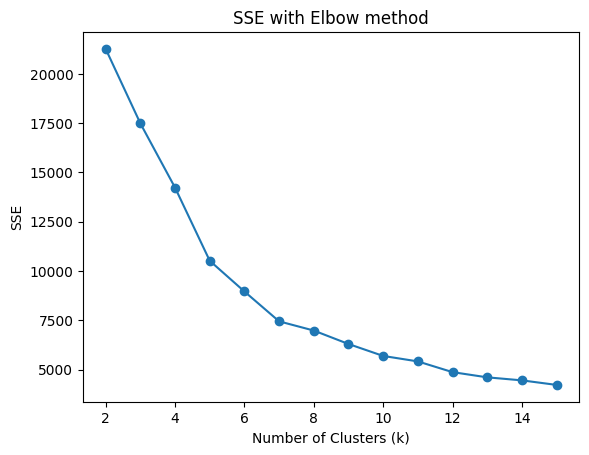

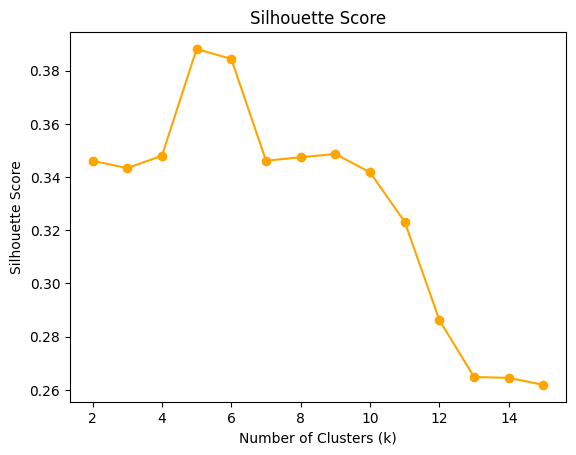

In [3061]:
k_means_evaluation_plotting(results)

## Compute Kmeans algorithm with best K found
Analyzing the Elbow Method of SSE and the Silhouette Score, the optimal  k  values do not align. The Silhouette Score suggests  k = 5  as the optimal number of clusters, while the SSE indicates  k = 6  or  k = 7 . As a trade-off, we choose  k = 6 .

In [3062]:
kmeans_data = kmeans_run(data=pca_std_numeric_races, best_k=6, scaler=standardizer['scaler'])
best_kmeans = kmeans_data['best_kmeans']
centroids = kmeans_data['centroids']


Best k based on a trade-off between silhuoette score and sse: 6
k: 6, Number of iterations: 20
Centroids
[[6.45634424e+01 1.22290993e-02 2.09023354e+02 8.23977197e+02
  1.83099257e+05]
 [7.60460993e+01 3.00357664e-02 1.15388830e+03 1.09035106e+03
  1.46040585e+05]
 [1.28333333e+02 1.80973576e-02 3.49143333e+04 8.95000000e+02
  1.97866667e+05]
 [6.14460227e+01 1.20127561e-02 1.12387074e+02 8.72784091e+02
  3.21285369e+04]
 [2.63163065e+02 1.23034037e-02 3.08014735e+02 9.21041257e+02
  2.47955678e+05]
 [9.77749361e+01 1.17806957e-02 3.67618286e+02 1.63688747e+03
  1.85870205e+05]]


In [3063]:
# count points for each cluster
cluster_counts = pd.Series(best_kmeans.labels_).value_counts().sort_index()

print("Number of points for each cluster")
print(cluster_counts)

Number of points for each cluster
0    2721
1     563
2       3
3     704
4     509
5     781
Name: count, dtype: int64


In [3064]:
numeric_races_df = numeric_races_df.copy() 
# Add Cluster as a column to the dataset
numeric_races_df['Cluster'] = best_kmeans.labels_

# Compute statistics for each feature grouped by cluster
detailed_cluster_stats = numeric_races_df.groupby('Cluster').agg(['mean', 'median', 'min', 'max'])

detailed_cluster_stats.columns = ['_'.join(col) for col in detailed_cluster_stats.columns]

display(detailed_cluster_stats)


,points_mean,points_median,points_min,points_max,climb/length_mean,climb/length_median,climb/length_min,climb/length_max,median_delta_mean,median_delta_median,median_delta_min,median_delta_max,startlist_quality_mean,startlist_quality_median,startlist_quality_min,startlist_quality_max,length_mean,length_median,length_min,length_max
Cluster,,,,,,,,,,,,,,,,,,,,
0,64.552738,50.0,18,150,0.012236,0.012309,0.000670,0.028710,209.617604,41.0,0.0,2368.5,823.958471,838.0,115,1269,183088.673282,181700.0,105900,292000
1,76.181172,80.0,30,100,0.030063,0.025735,0.014006,0.317000,1153.365897,1172.0,0.0,4751.0,1092.735346,995.0,251,2047,145863.214920,161300.0,1000,250000
2,128.333333,80.0,80,225,0.018097,0.016523,0.015263,0.022506,34914.333333,33140.0,25223.0,46380.0,895.000000,892.0,735,1058,197866.666667,201600.0,164000,228000
3,61.446023,50.0,18,100,0.012013,0.011389,0.000191,0.035789,112.387074,56.0,0.0,642.0,872.784091,842.5,156,1872,32128.536932,21750.0,1150,110200
4,263.163065,275.0,225,350,0.012303,0.013252,0.001265,0.021826,308.014735,270.0,0.0,1714.0,921.041257,874.0,241,1794,247955.677800,255000.0,175000,305000
5,97.772087,100.0,50,100,0.011760,0.010624,0.000069,0.032345,367.337388,113.0,0.0,2419.0,1636.615877,1685.0,1220,2047,185991.037132,192500.0,5400,338000


## Distribution of points for each feature across clusters

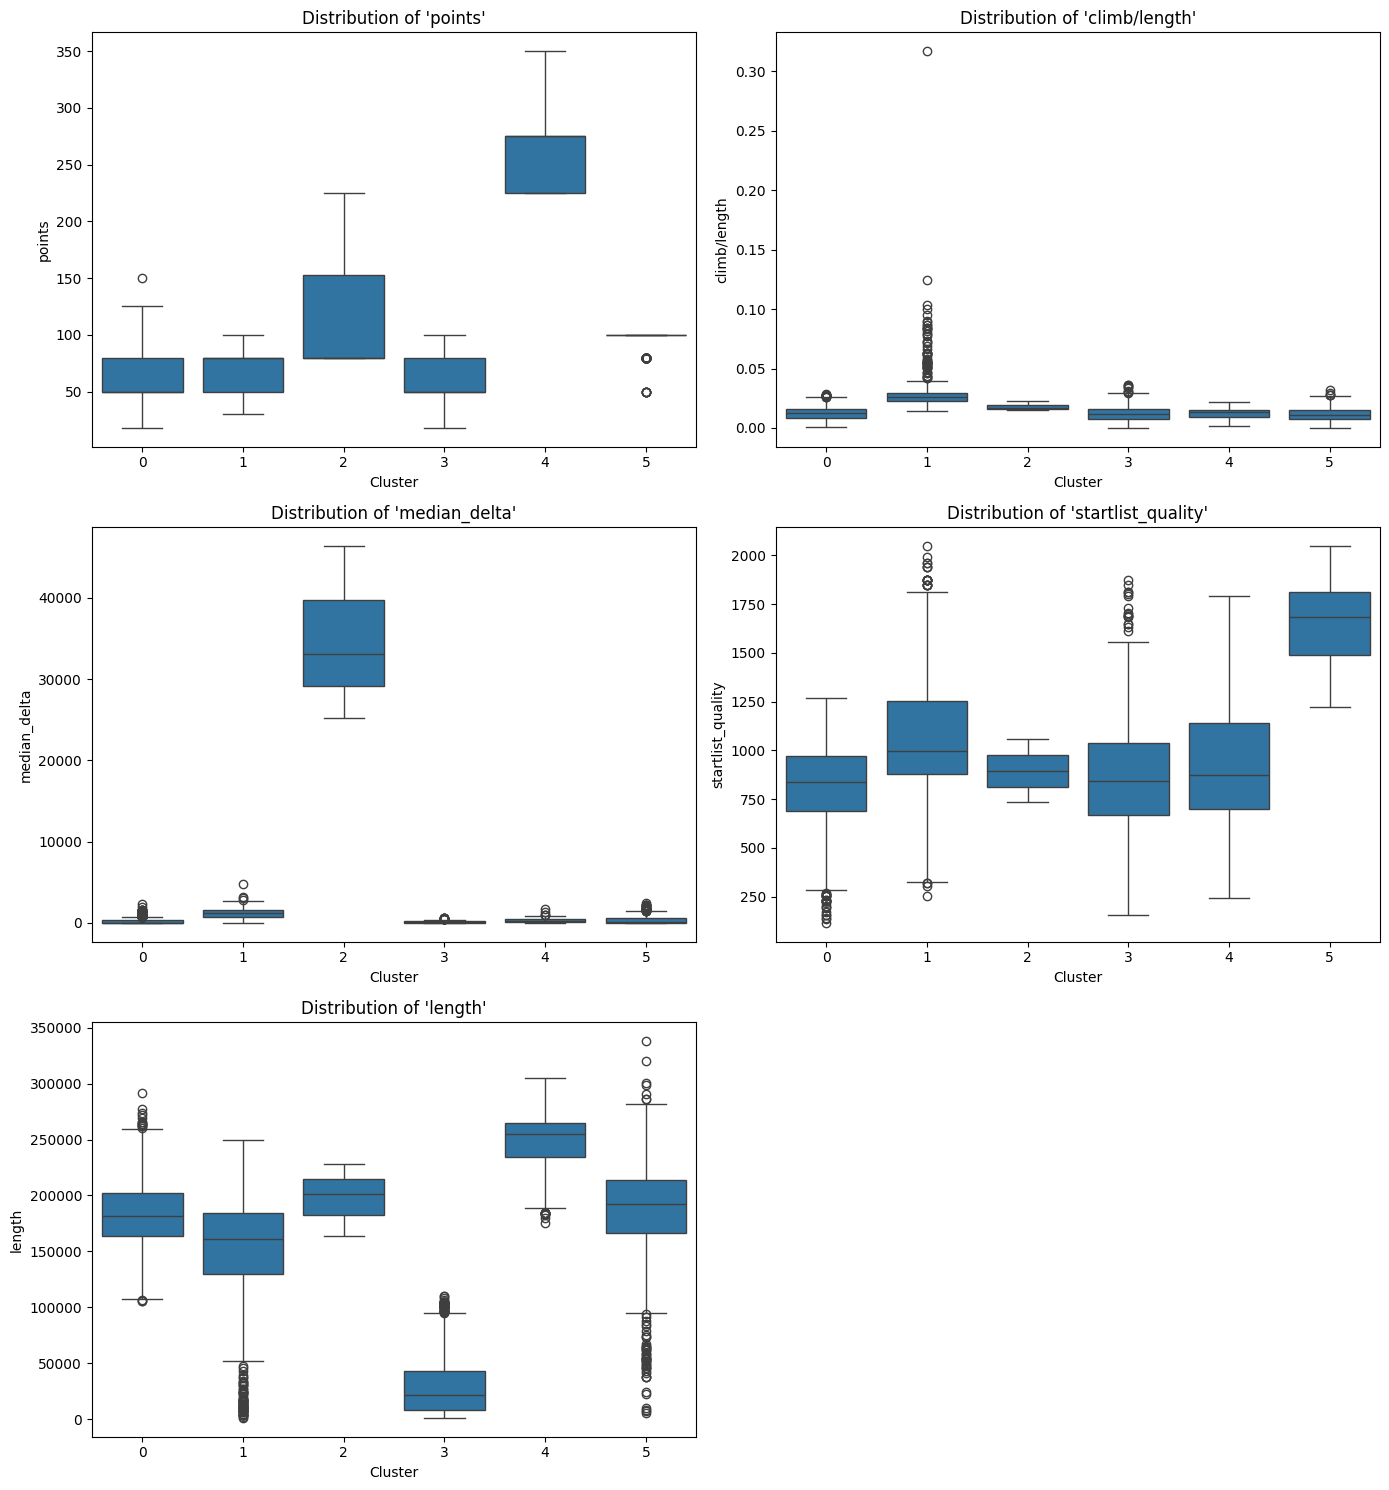

In [3065]:
clusters_box_plot(numeric_races_df)

### Box-plots analysis

By analying the box-plots above, we can try to analyze the 6 clusters by considering points distribution for each feature:
- **Cluster 0** (2721 points): 
  
  - **_points_**: the median is relatively low, ~50, and the IQR is narrow, ranging from ~50 up to ~80. There are few outliers on ~150.
  
  - **_climb/lenght_**: median is about ~0.01 and there are some outliers extending up to ~0.03.

  - **_median\_delta_**: IQR is extremely narrow and median is ~100, with a lot of high-end outliers up to ~2000. 

  - **_startlist\_quality_**:  IQR ranges from ~700 to ~ 900 with a median value of about ~ 850. There are many low-end outliers close to ~100.

  - **_length_**: here we have a relatively tight IQR, ~[160000, 200000], with a median on about ~180000. There are some low-end outliers and many high-end outliers up to ~2900000.

- **Cluster 1** (563 points): 
  
  - **_points_**: IQR is similar to the ones of the Cluster 0, slighlty higher with a median ~80. No outliers spotted here.
  
  - **_climb/lenght_**: this cluster has the highest ratio climb/length, meaning that Cluster 1 has the largest number of steep races with a median value about ~0.03. There are many outliers in the upper end, with some of these extending beyond 0.30. 

  - **_median\_delta_**: IQR is higher and wider than the one in Cluster 0. Also here, there are some high-end outliers exteding up to ~50000.
  
  - **_startlist\_quality_**: IQR is relatively wide and it extends from ~900 to ~1250 and the median is ~1000. So races in this cluster are attended by "stronger" cyclists compared to the Cluster 0. There are outliers on both the lower and the upper part, reaching over 2000.

  - **_length_**: races of this cluster are shorter than the ones in Cluster 0. The IQR is the widest, ranging from ~130000 to ~180000, and the median length is about ~160000. There are many low-end outlier lower ~10000.
  
- **Cluster 2** (3 points): extremely little cluster, 3 only points. It makes no sense to do analysis on this cluster. What is immediately noticeable is that it contains races with much higher values of median_delta compared to the other clusters.
  
- **Cluster 3** (704 points):
  
  - **_points_**: IQR here is approximately the same as ones in Cluster 0 and Cluster 1. There are no outliers.
  
  - **_climb/lenght_**: IQR and median very similar to the ones in Cluster 0. There are some high-end outliers, up to ~0.04.

  - **_median\_delta_**: this cluster has the narrowest IQR, and some high-end outliers.
  
  - **_startlist\_quality_**: IQR is relatively wide, with a median value of ~850. Many outliers reside in the upper part, extending up to ~1900.

  - **_length_**: the races in this cluster are the shortest, with a median of ~20000. Some outliers extend beyond 100000.
  
- **Cluster 4** (509 points):
  
  - **_points_**: the highest number of points are awarded to races in this cluster. The median number of points is ~275. There are no outliers.
  
  - **_climb/lenght_**: IQR is narrower than that of Cluster 3, and the median is slightly higher. There are no outliers.

  - **_median\_delta_**: IQR is slightly higher compared to the ones of Cluster 0 and Cluster 3. There are some outliers in the upper part.
  
  - **_startlist\_quality_**: IQR here is the widest, with a range between ~740 and ~1150 and a median value of about ~870. There are no outliers.

  - **_length_**: the races in this cluster are the longest, with a median beyond 250000. There are some low-end outliers close to ~175000.
  
 - **Cluster 5** (781 points):
  
  - **_points_**: IQR is the narrowest here, showing relatively low variability in points. The median value is also the max value, and it is approximately ~100. There are some low-end outliers, the lowest is approximately ~50.
  
  - **_climb/lenght_**: IQR is pretty similar to the ones of Cluster 0 and Cluster 3. Also here there are outliers in the upper part.

  - **_median\_delta_**: in this cluster median_delta IQR is the second widest, behind only that of cluster 1. Median is approximately ~100.
  
  - **_startlist\_quality_**: the races here have the highest startlist_quality values, meaning that these races are attended by the strongest cyclists. IQR ranges from about ~1500 to ~1850 with a median value of ~1700. There are no outliers.

  - **_length_**: the IQR is relatively wide, ranging from ~170000 to ~220000 with a median of ~190000. There are a lot of outliers on both the lower and the upper part. The minimum outlier is about ~5000 and the maximum is just under 350000.

Based on the analysis provided, here’s what we can infer about the clusters:
#### Cluster 0
Cluster 0 represents the most prevalent race type in the dataset. These races are of relatively low importance, with modest points awarded to participants. They are predominantly flat, and have minimal climbing challenges. The startlist quality is average, with most races attracting mid-level cyclists. The race lengths are moderate. Overall, Cluster 0 contains, let's say, standard races.

#### Cluster 1
Cluster 1 includes races which have the highest climb/length ratios. While the races are not excessively long, they attract stronger cyclists than Cluster 0, given the higher the startlist quality values. These races are likely to be shorter and with more climbs.

#### Cluster 2
Too few points to draw any conclusions

#### Cluster 3
Cluster 3 contains the shortest races with predominantly flat profiles. These races are quite competitive, with close finishes and minimal performance variability. The short race lengths suggest that these are likely criteriums or one-day events.

#### Cluster 4
Cluster 4 consists of highly prestigious races that reward participants with the highest number of points. These races are characterized by long distances and moderate climbing intensity. This cluster likely includes high-value stage races that offer significant rewards.

#### Cluster 5
Cluster 5 contains races that stand out for their high startlist quality, attracting the strongest cyclists in the dataset. These races are mid-length and predominantly flat. Points are moderately high but not as significant as in Cluster 4. The variability in race lengths and the outcomes (median_delta) is higher than in other clusters. These races are the ones in which the best cyclists compete.

## Clusters visualization with feature distributions and centroids 

/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_40803/1658901490.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


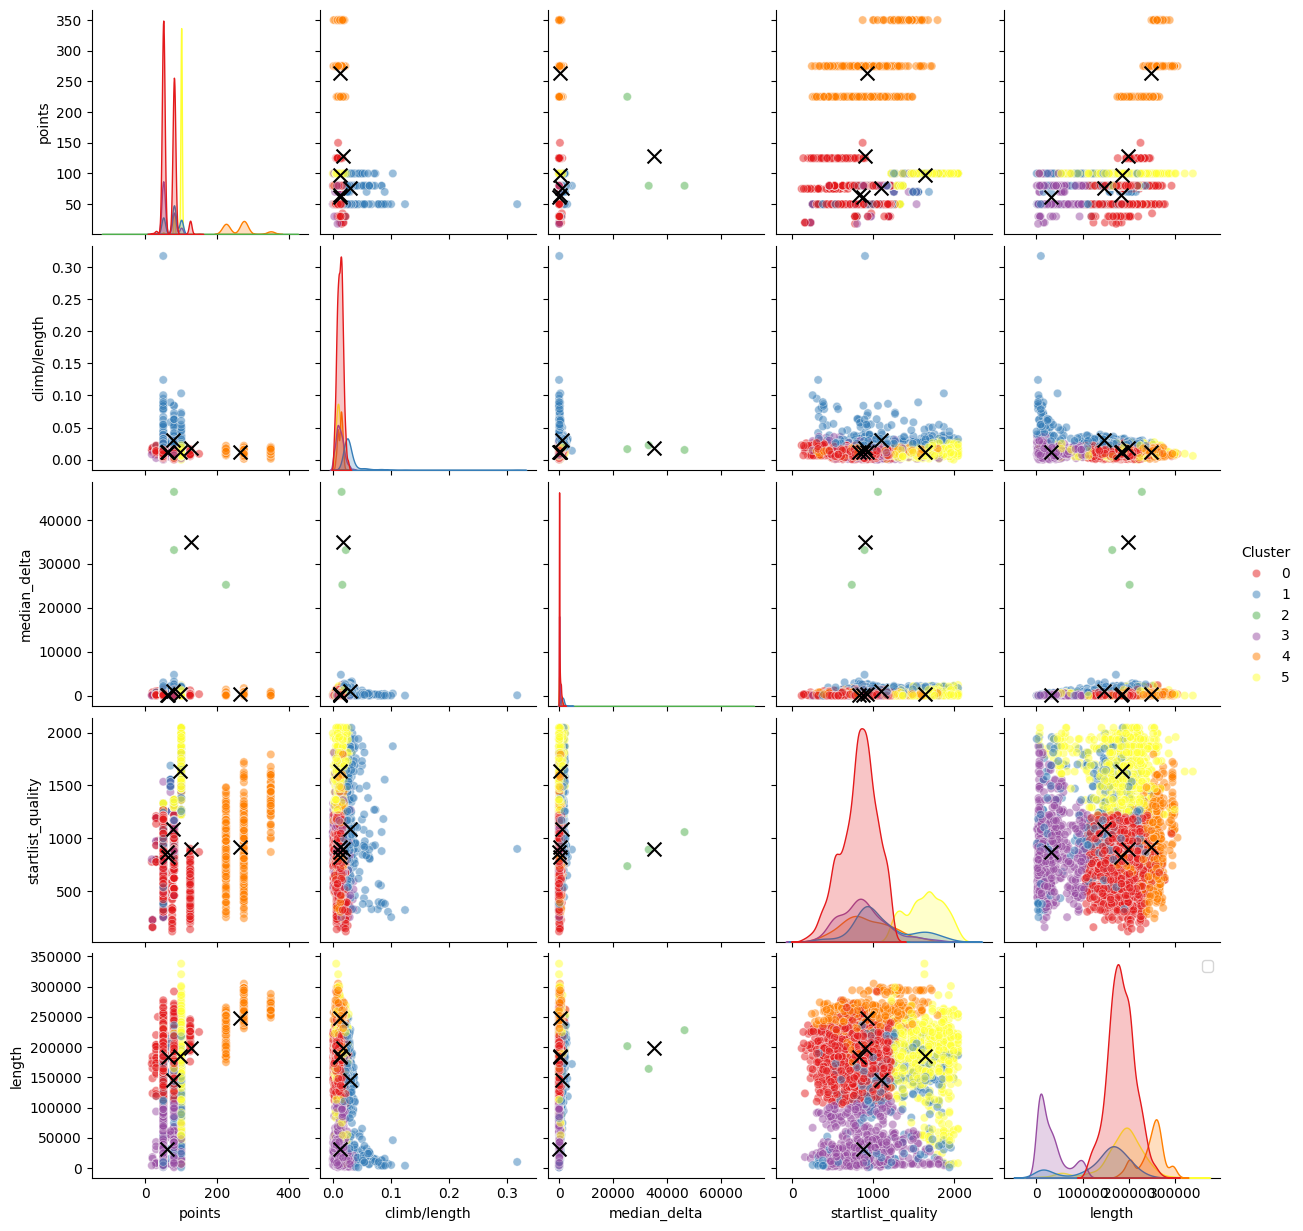

In [3066]:
clusters_pairplot(numeric_races_df, centroids)

### Pairplot analysis

By analyzing the paiplot above, we can try to analyze the 6 clusters and try to catch any relationships and patterns between the characteristics of the clusters that we were unable to catch with the box plots

- **Cluster 0**: no clear relationships or patterns identified

- **Cluster 1**:
  - **_climb\_length_** vs **length**: as length increases, there is a weak tendency for climb/length to decrese, which may suggest that longer races are slightly flatter or have less climbing intensity in this cluster.
  
- **Cluster 2**: too few point to get an effective analysis from the pairplot
  
- **Cluster 3**:
  - **_startlist\_quality** vs **length** it seems there is a subtle relationship between those two features in Cluster 3. This is a negative relation, as the length of the races increases, the quality of the starting list tends to decrease.
  
- **Cluster 4**: 
  - **_points_** vs **_length_**:	there seems to be a weak correlation: as the length increases, points also increase slightly. So, longer races tend to give more points.

  - **_points_** vs **_startlist\_quality_**: higher points values in this cluster align with slightly higher statirst_quality.
  
  - **_length_** vs **_startlist\_quality_**: there seems to be a very weak positive correlation, especially for startirst_quality > 1000, where length of the races tends to increase with the quality of the starting list.
	
- **Cluster 5**:
  - **_points_** vs **_startlist\_quality_**: there is a very subtle relation, higher points values align with slightly higher statirst_quality.
  
  - **_startlist\_quality** vs **length**: also in this cluster seems to be a negative correlation between those two features. With better (higher) quality of the starting list, the length of the races seems to decrease.
 



 